# 迁移学习

实现源域直测、目标域训练和三种迁移学习策略，将源域建筑训练的LSTM模型迁移到目标域建筑。

## 迁移策略
1. **源域直测（Source-only）**：只在源域训练，不在目标域迁移，直接在目标域测试集预测
2. **目标域训练（Target-only）**：不在源域训练，只在目标域训练集上从零训练模型，作为主参照
3. **全层微调（Full fine-tune）**：先在源域训练，再在目标域微调全部层
4. **冻结LSTM微调（Frozen-LSTM fine-tune）**：先在源域训练，再冻结 LSTM 层并微调其它层
5. **冻结特征回归（Frozen-feature regression）**：先在源域训练，再冻结特征提取层并重新训练新的回归层

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
from scipy import stats
import joblib

# 从 src 模块导入共享配置和函数
from src import (
    # preprocessing
    load_data,
    create_sequences,
    # models
    LSTMPredictor,
    FeatureExtractorRegressor,
    # training
    set_seed,
    evaluate,
    LoadDataset,
    EarlyStopping,
    run_epoch,
    predict,
    # visualization
    setup_plot_style,
    plot_training_history,
    plot_predictions,
    # config
    BASE_DIR,
    MODEL_DIR,
    SCALER_DIR,
    FIGURES_DIR,
    TARGET_COL,
    TIME_COL,
    SEED,
)

# 超参数配置
LOOKBACK = 24   # 输入窗口长度（小时）
HORIZON = 1     # 预测步长（小时）
BATCH_SIZE = 72
EPOCHS = 100
HIDDEN_SIZE = 128
REPEAT_SEEDS = [7, 21, 84, 2024]
METRIC_COLS = ['MAE', 'RMSE', 'CV-RMSE', 'MAPE', 'R2']
set_seed(SEED)
criterion = nn.L1Loss()

# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

setup_plot_style()
plt.rcParams['font.family'] = 'DejaVu Sans'

## 数据准备

In [2]:
# 数据路径
SOURCE_TRAIN_PATH = BASE_DIR / 'source_train_std.csv'  # 源域全量数据
TARGET_TRAIN_PATH = BASE_DIR / 'target_train_std.csv'
TARGET_VAL_PATH = BASE_DIR / 'target_val_std.csv'
TARGET_TEST_PATH = BASE_DIR / 'target_test_std.csv'

# 读取源域数据（全量数据）
source_full_df = load_data(SOURCE_TRAIN_PATH).dropna(subset=[TARGET_COL]).reset_index(drop=True)

# 加载目标域 scaler
target_scaler = joblib.load(SCALER_DIR / 'target_load_scaler.joblib')

# 从源域全量数据中划分部分作为验证集（用于早停）
source_val_ratio = 0.2
source_n = len(source_full_df)
source_val_end = int(source_n * source_val_ratio)

source_train_df = source_full_df.iloc[:-source_val_end].reset_index(drop=True)
source_val_df = source_full_df.iloc[-source_val_end:].reset_index(drop=True)

# 读取目标域数据
target_train_df = load_data(TARGET_TRAIN_PATH).dropna(subset=[TARGET_COL]).reset_index(drop=True)
target_val_df = load_data(TARGET_VAL_PATH).dropna(subset=[TARGET_COL]).reset_index(drop=True)
target_test_df = load_data(TARGET_TEST_PATH).dropna(subset=[TARGET_COL]).reset_index(drop=True)

# 确定特征列（除时间戳外）
FEATURE_COLS = [c for c in source_train_df.columns if c != TIME_COL]
input_size = len(FEATURE_COLS)

# 构造序列
X_source_train, y_source_train = create_sequences(source_train_df, FEATURE_COLS, TARGET_COL, LOOKBACK, HORIZON)
X_source_val, y_source_val = create_sequences(source_val_df, FEATURE_COLS, TARGET_COL, LOOKBACK, HORIZON)

X_target_train, y_target_train = create_sequences(target_train_df, FEATURE_COLS, TARGET_COL, LOOKBACK, HORIZON)
X_target_val, y_target_val = create_sequences(target_val_df, FEATURE_COLS, TARGET_COL, LOOKBACK, HORIZON)
X_target_test, y_target_test = create_sequences(target_test_df, FEATURE_COLS, TARGET_COL, LOOKBACK, HORIZON)

print(f"　源域训练序列: {X_source_train.shape}")
print(f"　源域验证序列: {X_source_val.shape}")
print(f"\n目标域训练序列: {X_target_train.shape}")
print(f"目标域验证序列: {X_target_val.shape}")
print(f"目标域测试序列: {X_target_test.shape}")

　源域训练序列: (6920, 24, 45)
　源域验证序列: (1732, 24, 45)

目标域训练序列: (1497, 24, 45)
目标域验证序列: (307, 24, 45)
目标域测试序列: (308, 24, 45)


In [3]:
# 数据流：DataFrame -> create_sequences 生成 ndarray -> LoadDataset 适配 PyTorch
torch_datasets = {
    'source_train': LoadDataset(X_source_train, y_source_train),
    'source_val': LoadDataset(X_source_val, y_source_val),
    'target_train': LoadDataset(X_target_train, y_target_train),
    'target_val': LoadDataset(X_target_val, y_target_val),
    'target_test': LoadDataset(X_target_test, y_target_test),
}

def fit_model(model, train_loader, val_loader, optimizer, lr_scheduler, early_stopping) -> tuple:
    train_losses = []
    val_losses = []
    for epoch in range(EPOCHS):
        train_loss = run_epoch(model, train_loader, criterion, device, optimizer)
        val_loss = run_epoch(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        lr_scheduler.step(val_loss)

        if early_stopping(val_loss, model, epoch):
            break

    early_stopping.restore(model)
    return train_losses, val_losses, early_stopping.get_best_info()


def make_result(seed: int, strategy: str, metrics: dict, best_info: dict = None, train_losses: list = None) -> dict:
    return {
        'seed': seed,
        '策略': strategy,
        **metrics,
        'best_epoch': np.nan if best_info is None else best_info['best_epoch'],
        'best_val_loss': np.nan if best_info is None else best_info['best_loss'],
        'epochs': 0 if train_losses is None else len(train_losses),
    }


def train_source(seed: int) -> dict:
    set_seed(seed)
    source_train_loader = DataLoader(
        torch_datasets['source_train'],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=torch.Generator().manual_seed(seed),
    )
    source_val_loader = DataLoader(torch_datasets['source_val'], batch_size=BATCH_SIZE, shuffle=False)
    model = LSTMPredictor(input_size=input_size, hidden_size=HIDDEN_SIZE, horizon=HORIZON).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    lr_scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=4, min_lr=1e-5)
    early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

    train_losses, val_losses, best_info = fit_model(
        model, source_train_loader, source_val_loader, optimizer, lr_scheduler, early_stopping
    )

    torch.save(model.state_dict(), MODEL_DIR / 'pretrained_source.pt')
    plot_training_history(
        train_losses, val_losses, 'Source Domain Training History',
        save_path=FIGURES_DIR / '源域训练_损失曲线.png'
    )

    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def run_source_only(seed: int, source_state: dict) -> dict:
    set_seed(seed)
    target_test_loader = DataLoader(torch_datasets['target_test'], batch_size=BATCH_SIZE, shuffle=False)
    model = LSTMPredictor(input_size=input_size, hidden_size=HIDDEN_SIZE, horizon=HORIZON).to(device)
    model.load_state_dict(source_state)

    y_pred = predict(model, target_test_loader, device)
    metrics = evaluate(y_target_test, y_pred, target_scaler)

    plot_predictions(
        y_target_test, y_pred, 'Source-only Predictions', target_scaler,
        save_path=FIGURES_DIR / '源域直测_预测对比.png'
    )

    return make_result(seed, '源域直测', metrics)


def run_target_only(seed: int) -> dict:
    set_seed(seed)
    target_train_loader = DataLoader(
        torch_datasets['target_train'],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=torch.Generator().manual_seed(seed),
    )
    target_val_loader = DataLoader(torch_datasets['target_val'], batch_size=BATCH_SIZE, shuffle=False)
    target_test_loader = DataLoader(torch_datasets['target_test'], batch_size=BATCH_SIZE, shuffle=False)
    model = LSTMPredictor(input_size=input_size, hidden_size=HIDDEN_SIZE, horizon=HORIZON).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    lr_scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=4, min_lr=1e-5)
    early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

    train_losses, val_losses, best_info = fit_model(
        model, target_train_loader, target_val_loader, optimizer, lr_scheduler, early_stopping
    )
    y_pred = predict(model, target_test_loader, device)
    metrics = evaluate(y_target_test, y_pred, target_scaler)

    torch.save(model.state_dict(), MODEL_DIR / 'transfer_target_only.pt')
    plot_training_history(
        train_losses, val_losses, 'Target-only Training History',
        save_path=FIGURES_DIR / '目标域训练_损失曲线.png'
    )
    plot_predictions(
        y_target_test, y_pred, 'Target-only Predictions', target_scaler,
        save_path=FIGURES_DIR / '目标域训练_预测对比.png'
    )

    return make_result(seed, '目标域训练', metrics, best_info, train_losses)


def run_full_fine_tune(seed: int, source_state: dict) -> dict:
    set_seed(seed)
    target_train_loader = DataLoader(
        torch_datasets['target_train'],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=torch.Generator().manual_seed(seed),
    )
    target_val_loader = DataLoader(torch_datasets['target_val'], batch_size=BATCH_SIZE, shuffle=False)
    target_test_loader = DataLoader(torch_datasets['target_test'], batch_size=BATCH_SIZE, shuffle=False)
    model = LSTMPredictor(input_size=input_size, hidden_size=HIDDEN_SIZE, horizon=HORIZON).to(device)
    model.load_state_dict(source_state)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    lr_scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=4, min_lr=1e-6)
    early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

    train_losses, val_losses, best_info = fit_model(
        model, target_train_loader, target_val_loader, optimizer, lr_scheduler, early_stopping
    )
    y_pred = predict(model, target_test_loader, device)
    metrics = evaluate(y_target_test, y_pred, target_scaler)

    torch.save(model.state_dict(), MODEL_DIR / 'transfer_full_fine_tune.pt')
    plot_training_history(
        train_losses, val_losses, 'Full fine-tune Training History',
        save_path=FIGURES_DIR / '全层微调_损失曲线.png'
    )
    plot_predictions(
        y_target_test, y_pred, 'Full fine-tune Predictions', target_scaler,
        save_path=FIGURES_DIR / '全层微调_预测对比.png'
    )

    return make_result(seed, '全层微调', metrics, best_info, train_losses)


def run_frozen_lstm_fine_tune(seed: int, source_state: dict) -> dict:
    set_seed(seed)
    target_train_loader = DataLoader(
        torch_datasets['target_train'],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=torch.Generator().manual_seed(seed),
    )
    target_val_loader = DataLoader(torch_datasets['target_val'], batch_size=BATCH_SIZE, shuffle=False)
    target_test_loader = DataLoader(torch_datasets['target_test'], batch_size=BATCH_SIZE, shuffle=False)
    model = LSTMPredictor(input_size=input_size, hidden_size=HIDDEN_SIZE, horizon=HORIZON).to(device)
    model.load_state_dict(source_state)

    for name, param in model.named_parameters():
        if 'lstm' in name:
            param.requires_grad = False

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-3, weight_decay=1e-4
    )
    lr_scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=4, min_lr=1e-6)
    early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

    train_losses, val_losses, best_info = fit_model(
        model, target_train_loader, target_val_loader, optimizer, lr_scheduler, early_stopping
    )
    y_pred = predict(model, target_test_loader, device)
    metrics = evaluate(y_target_test, y_pred, target_scaler)

    torch.save(model.state_dict(), MODEL_DIR / 'transfer_frozen_lstm_fine_tune.pt')
    plot_training_history(
        train_losses, val_losses, 'Frozen-LSTM fine-tune Training History',
        save_path=FIGURES_DIR / '冻结LSTM微调_损失曲线.png'
    )
    plot_predictions(
        y_target_test, y_pred, 'Frozen-LSTM fine-tune Predictions', target_scaler,
        save_path=FIGURES_DIR / '冻结LSTM微调_预测对比.png'
    )

    return make_result(seed, '冻结LSTM微调', metrics, best_info, train_losses)


def run_frozen_feature_regression(seed: int, source_state: dict) -> dict:
    set_seed(seed)
    target_train_loader = DataLoader(
        torch_datasets['target_train'],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=torch.Generator().manual_seed(seed),
    )
    target_val_loader = DataLoader(torch_datasets['target_val'], batch_size=BATCH_SIZE, shuffle=False)
    target_test_loader = DataLoader(torch_datasets['target_test'], batch_size=BATCH_SIZE, shuffle=False)
    pretrained = LSTMPredictor(input_size=input_size, hidden_size=HIDDEN_SIZE, horizon=HORIZON).to(device)
    pretrained.load_state_dict(source_state)
    model = FeatureExtractorRegressor(pretrained, horizon=HORIZON).to(device)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-3, weight_decay=1e-4
    )
    lr_scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=4, min_lr=1e-6)
    early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

    train_losses, val_losses, best_info = fit_model(
        model, target_train_loader, target_val_loader, optimizer, lr_scheduler, early_stopping
    )
    y_pred = predict(model, target_test_loader, device)
    metrics = evaluate(y_target_test, y_pred, target_scaler)

    torch.save(model.state_dict(), MODEL_DIR / 'transfer_frozen_feature_regression.pt')
    plot_training_history(
        train_losses, val_losses, 'Frozen-feature regression Training History',
        save_path=FIGURES_DIR / '冻结特征回归_损失曲线.png'
    )
    plot_predictions(
        y_target_test, y_pred, 'Frozen-feature regression Predictions', target_scaler,
        save_path=FIGURES_DIR / '冻结特征回归_预测对比.png'
    )

    return make_result(seed, '冻结特征回归', metrics, best_info, train_losses)


## 训练函数与多 seed 实验

源域直测、目标域训练和三种迁移学习策略在下方循环中按 `[*REPEAT_SEEDS, SEED]` 逐个执行。各函数内部自行构造所需 DataLoader、EarlyStopping 和学习率调度器，循环只保留执行顺序；主 `SEED` 放在最后，确保最终保存的同名模型和预测图来自主 `SEED`

- `run_source_only()` : 源域直测
- `run_target_only()` : 目标域训练
- `run_full_fine_tune()` : 全层微调
- `run_frozen_lstm_fine_tune()` : 冻结LSTM微调
- `run_frozen_feature_regression()` : 冻结特征回归

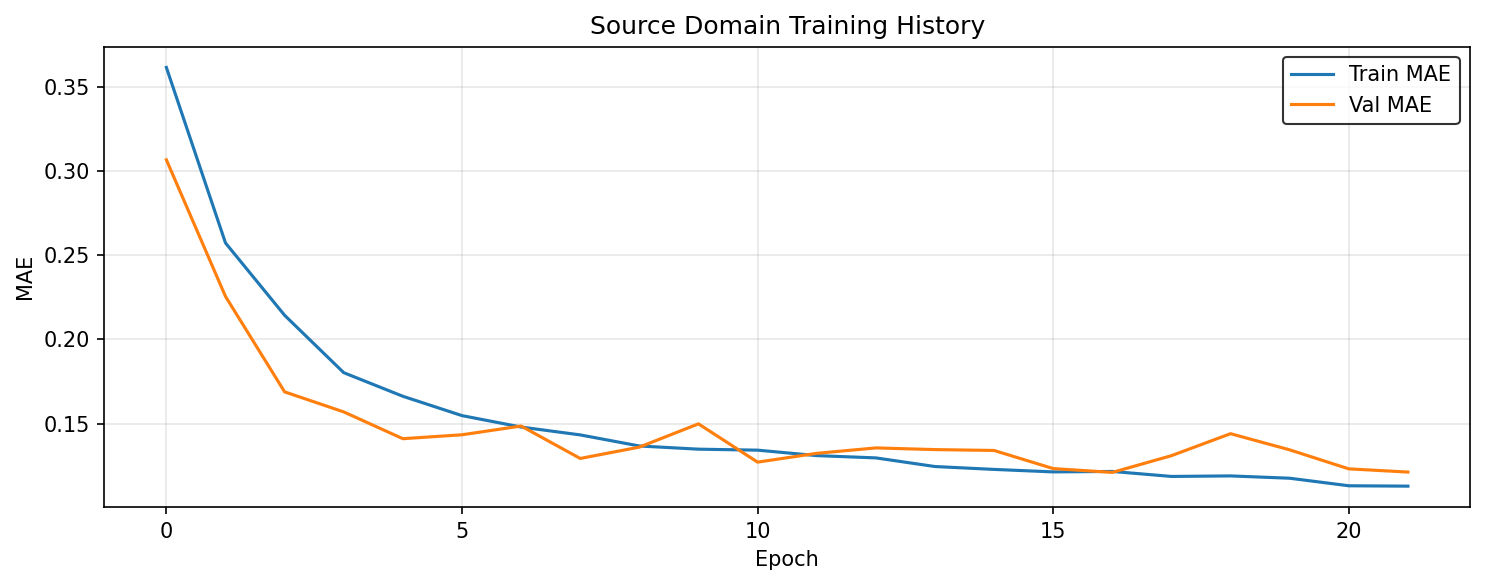

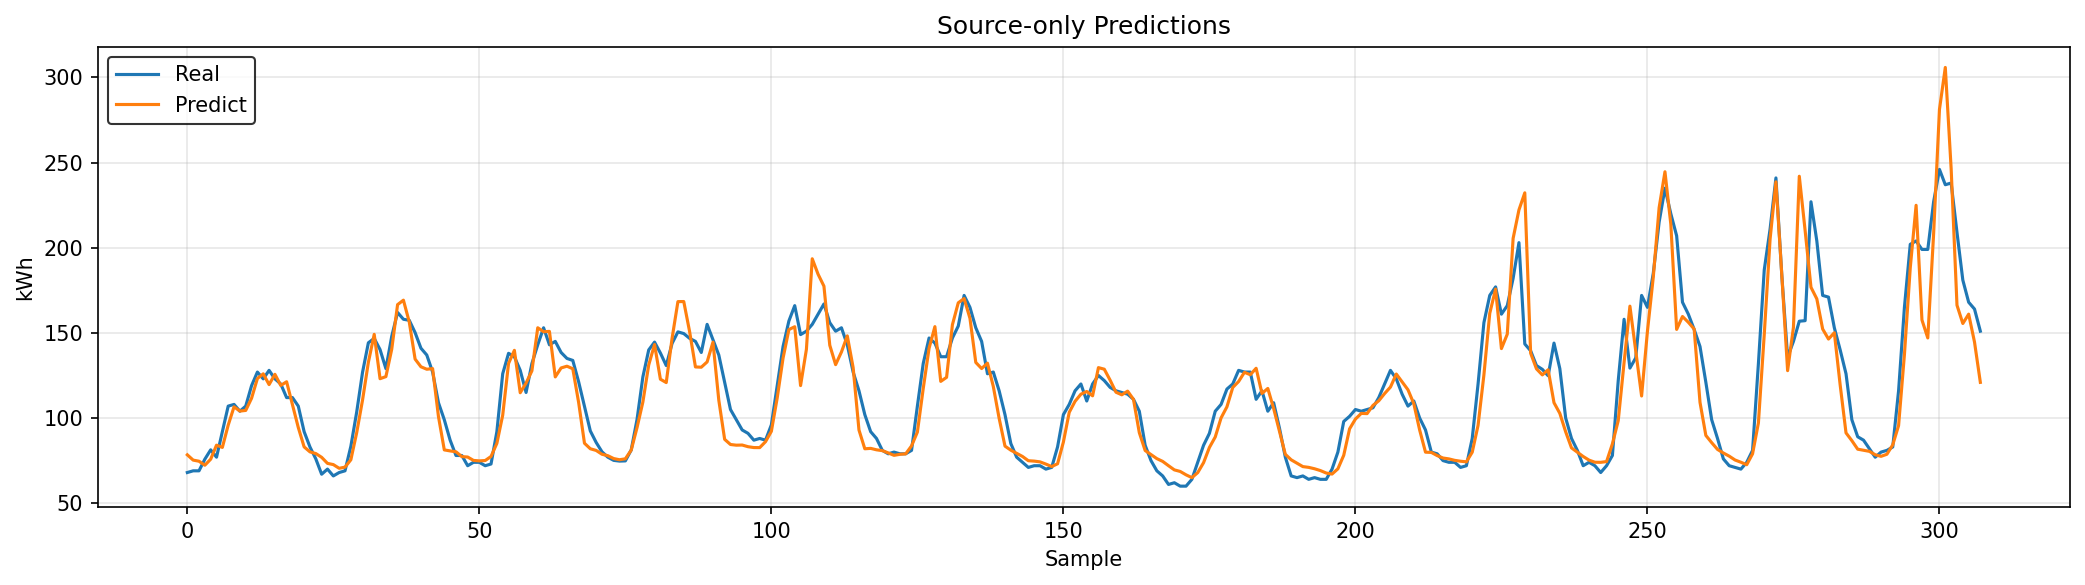

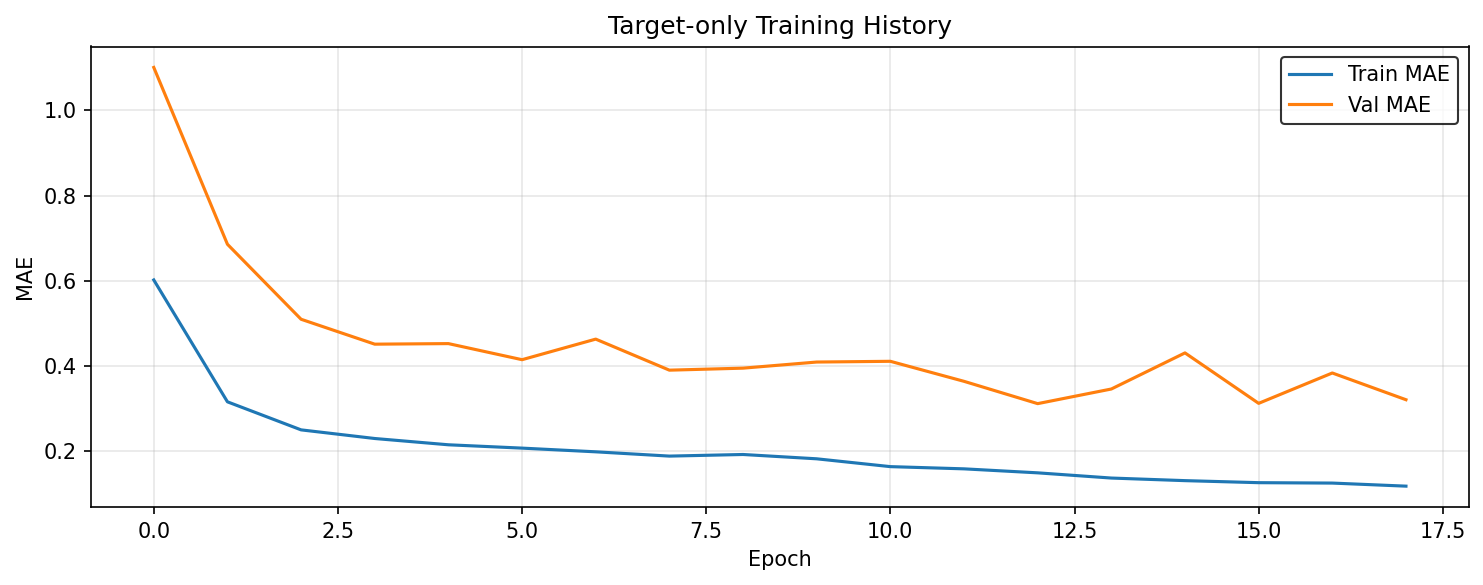

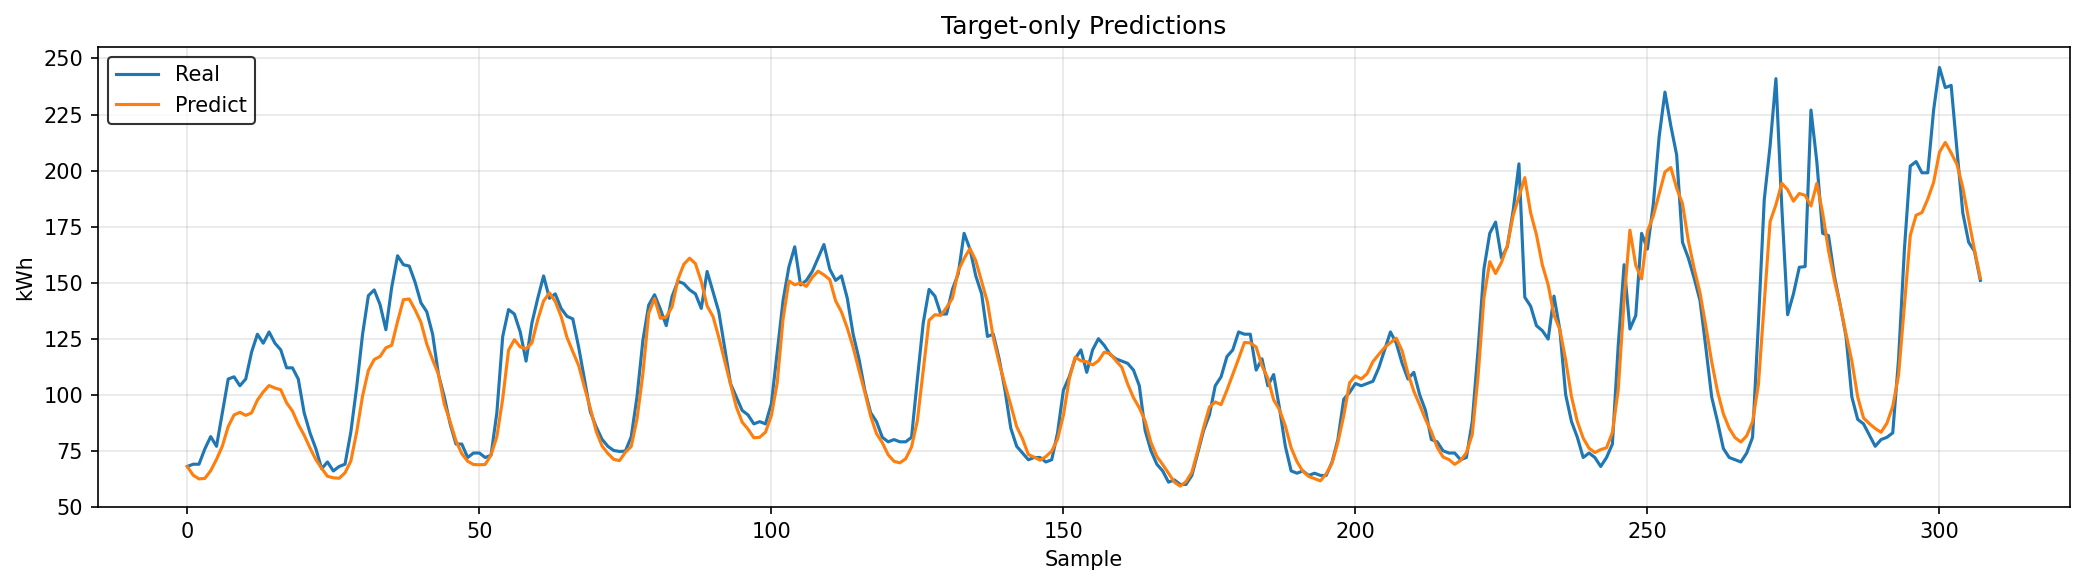

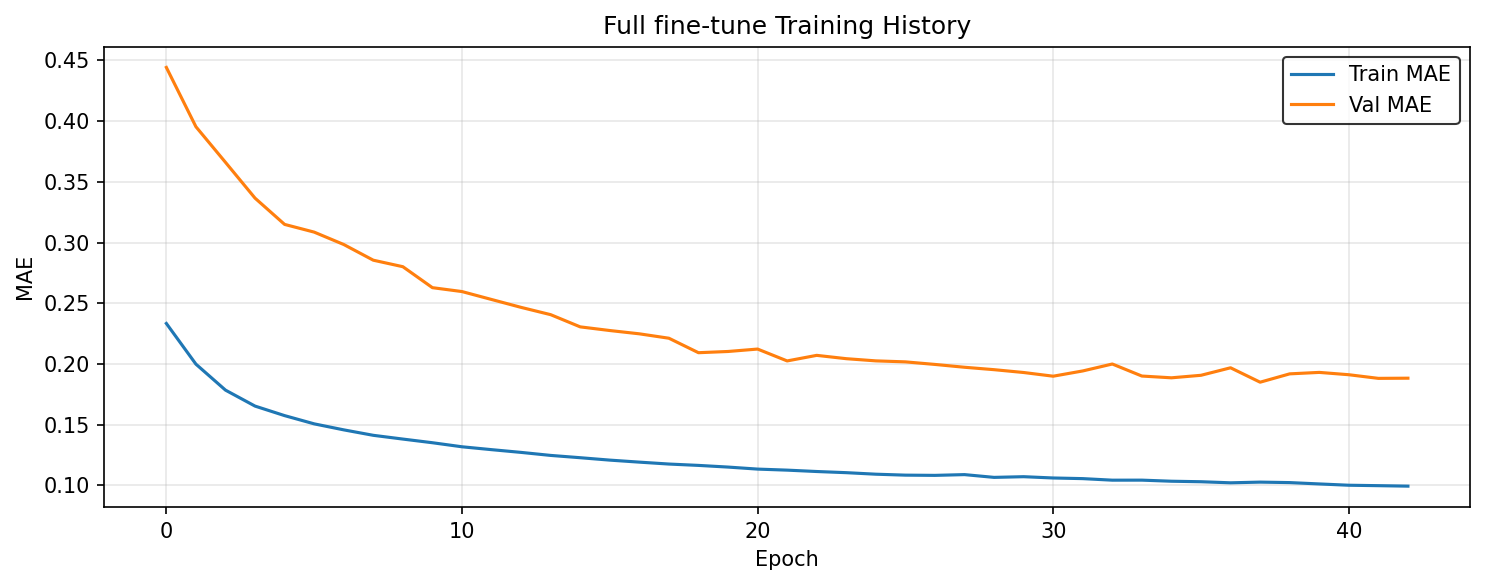

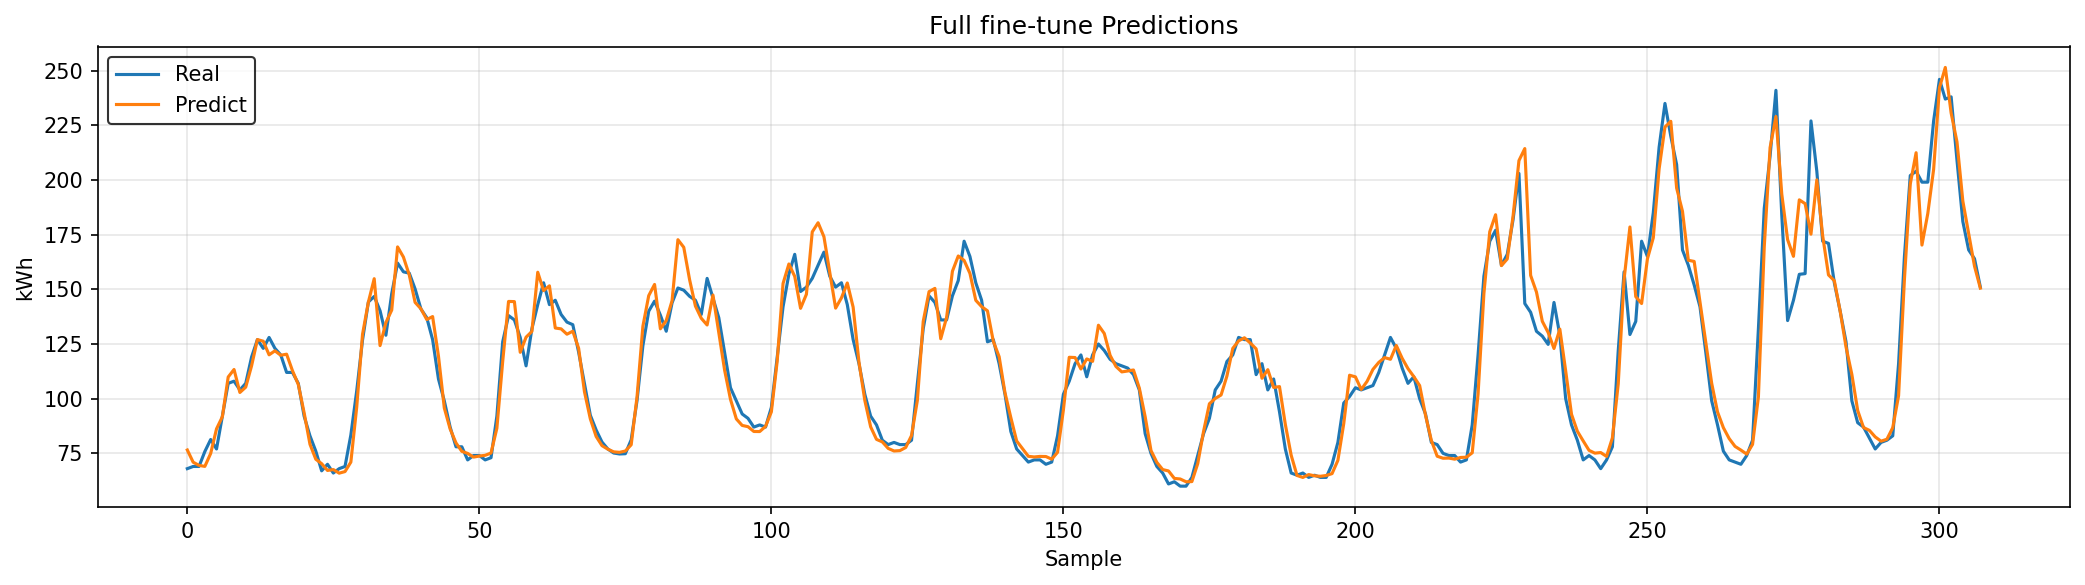

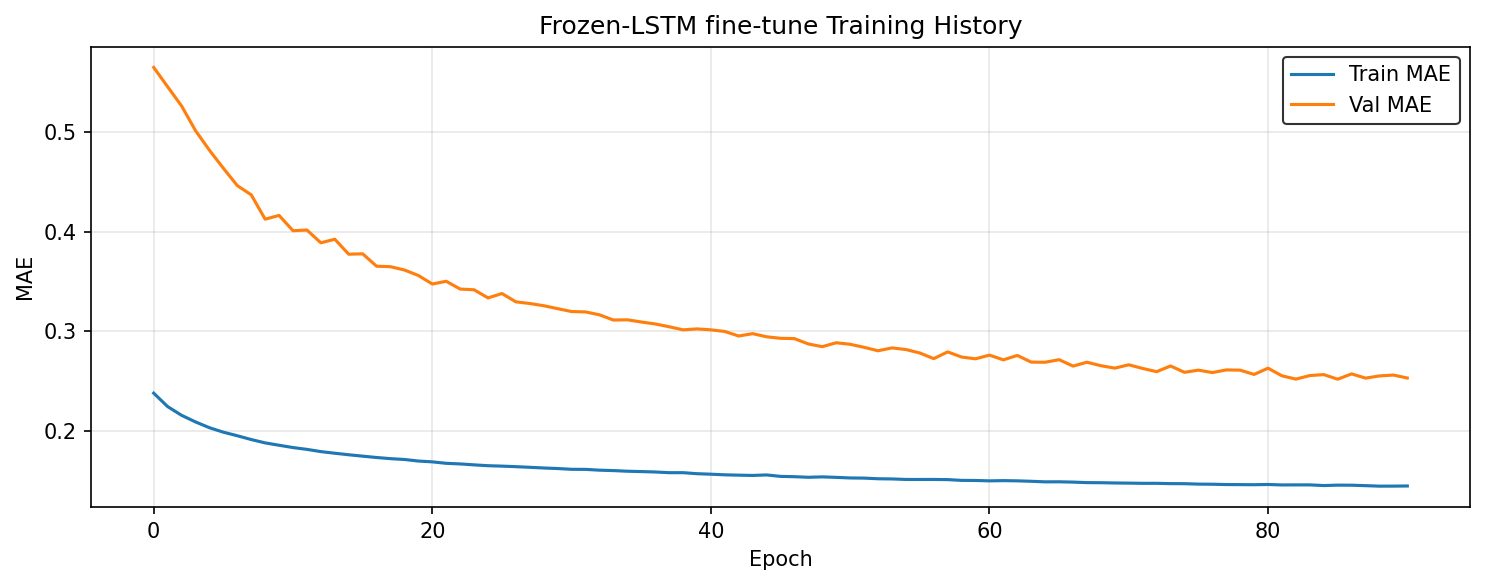

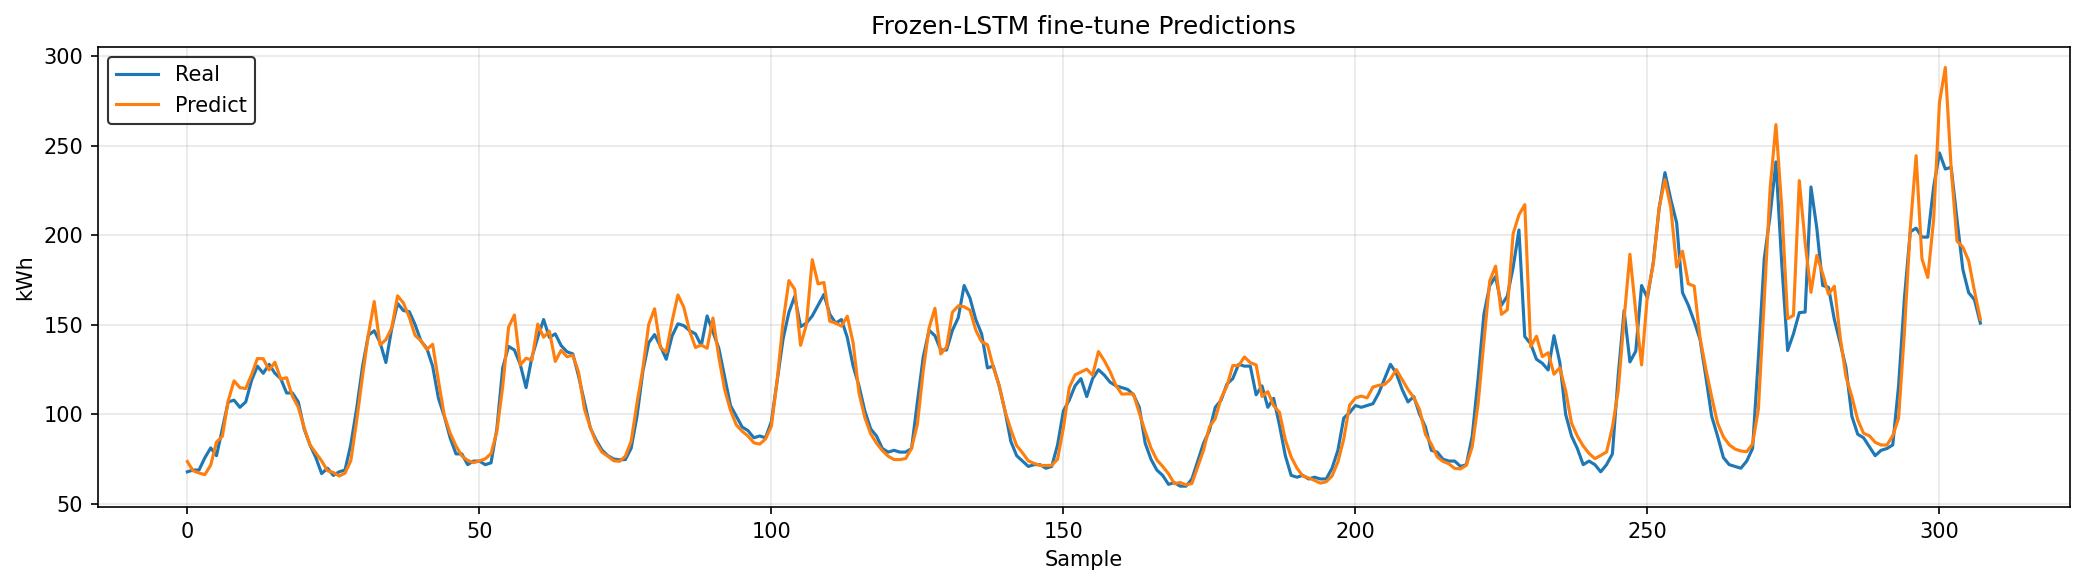

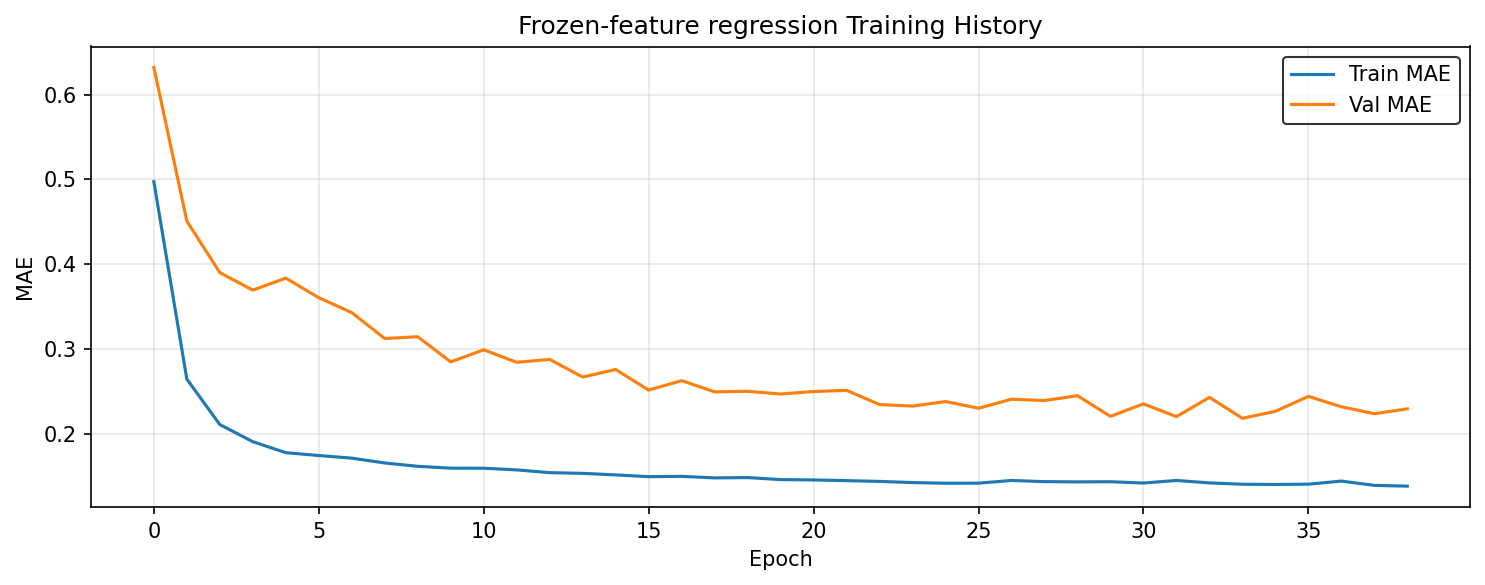

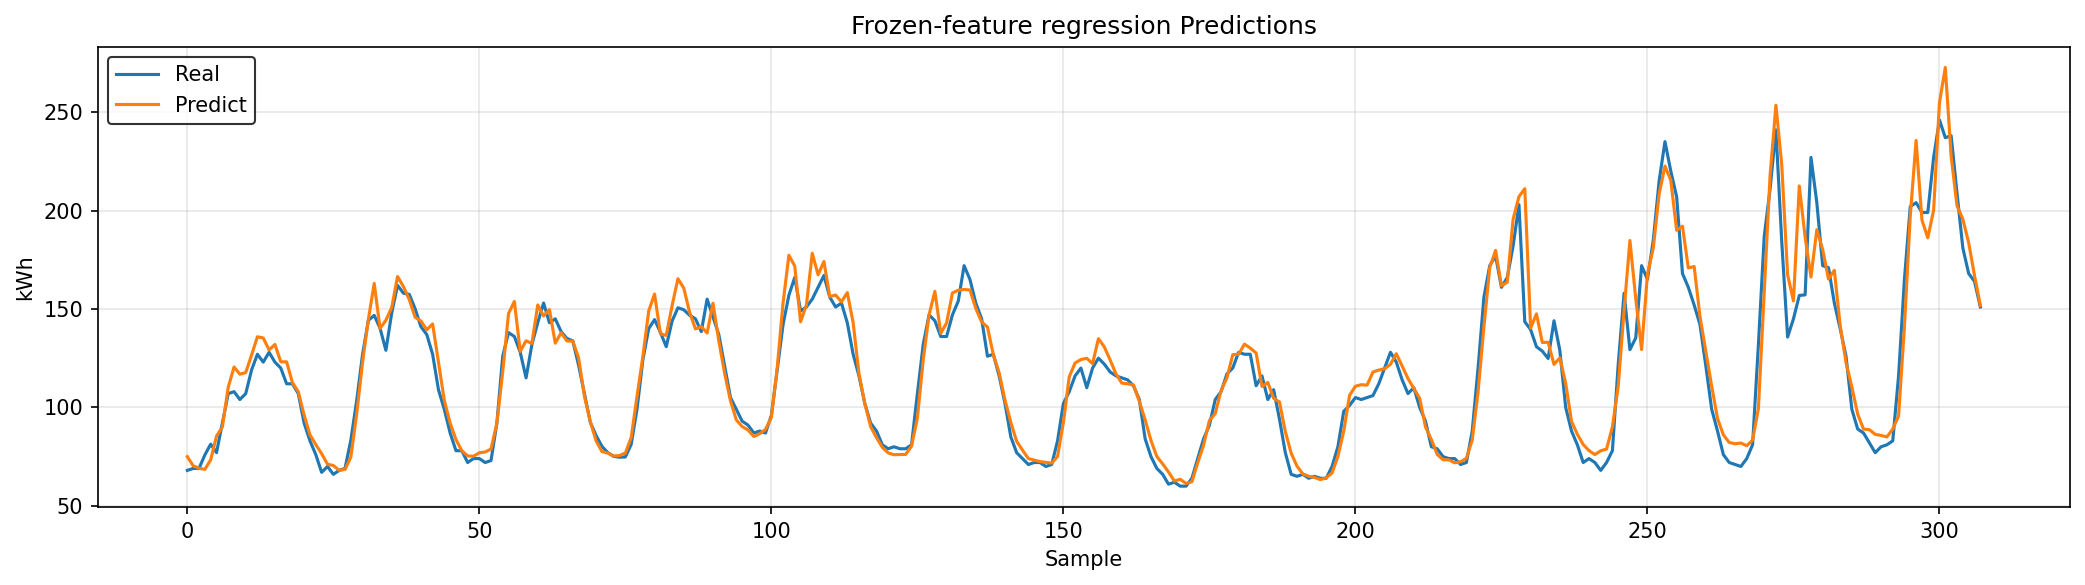

 >> 在 seed=7 下完成训练


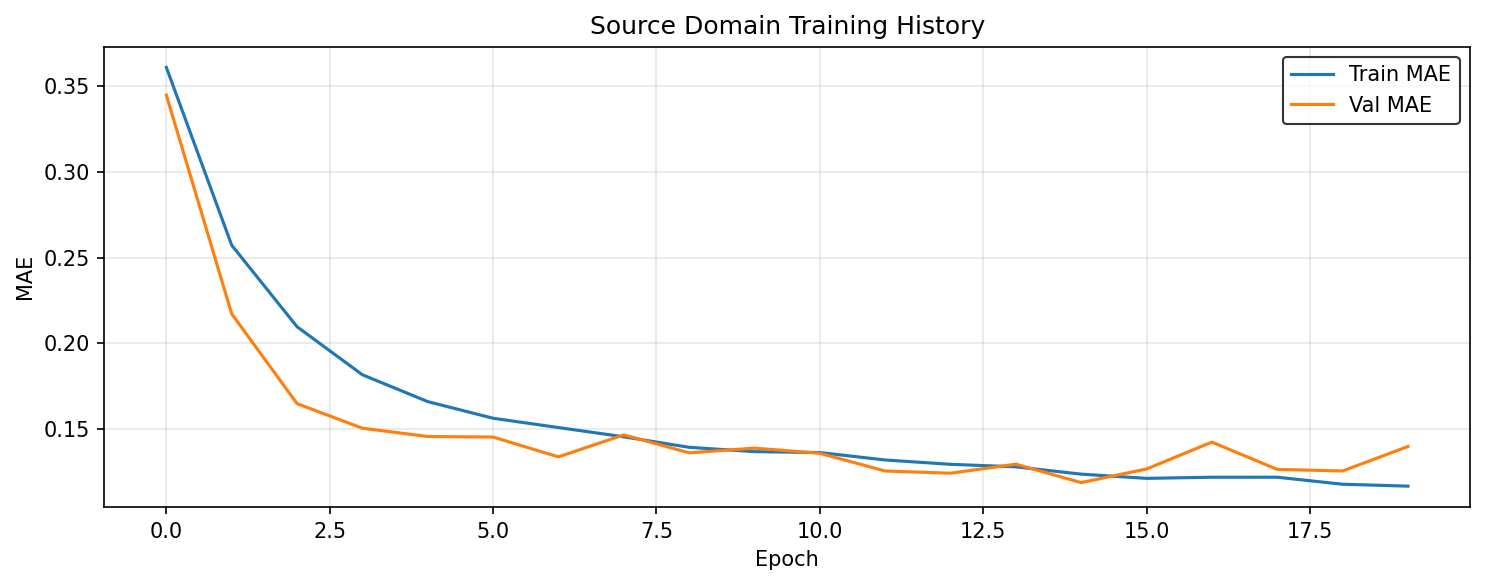

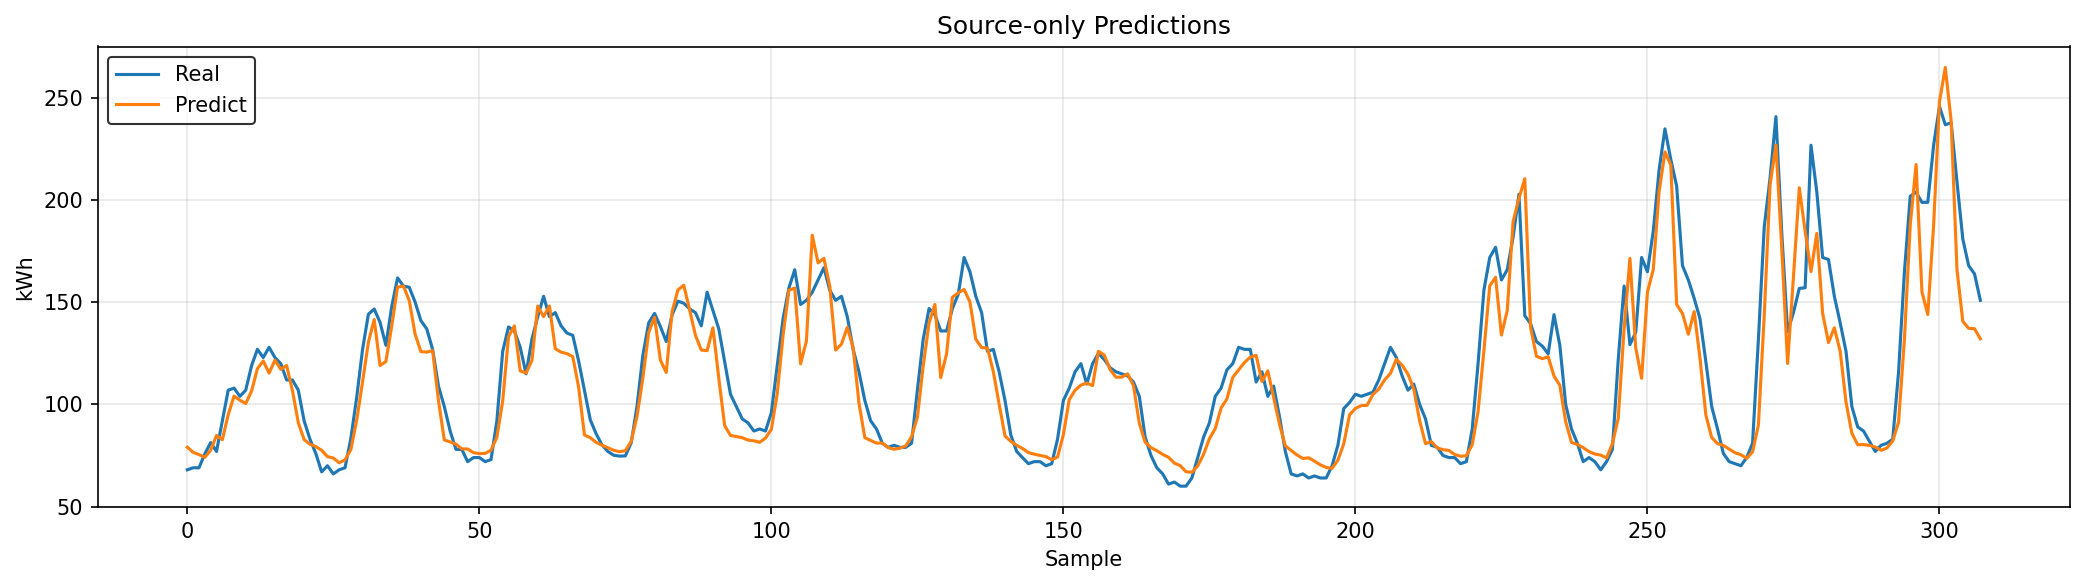

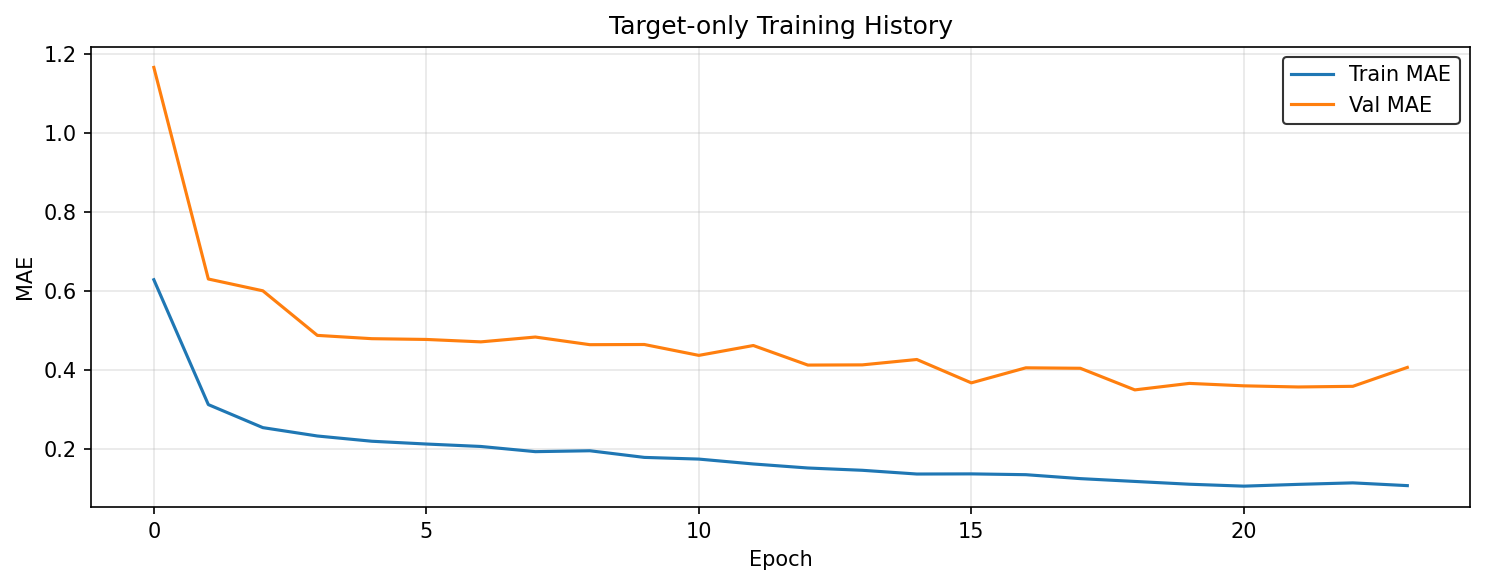

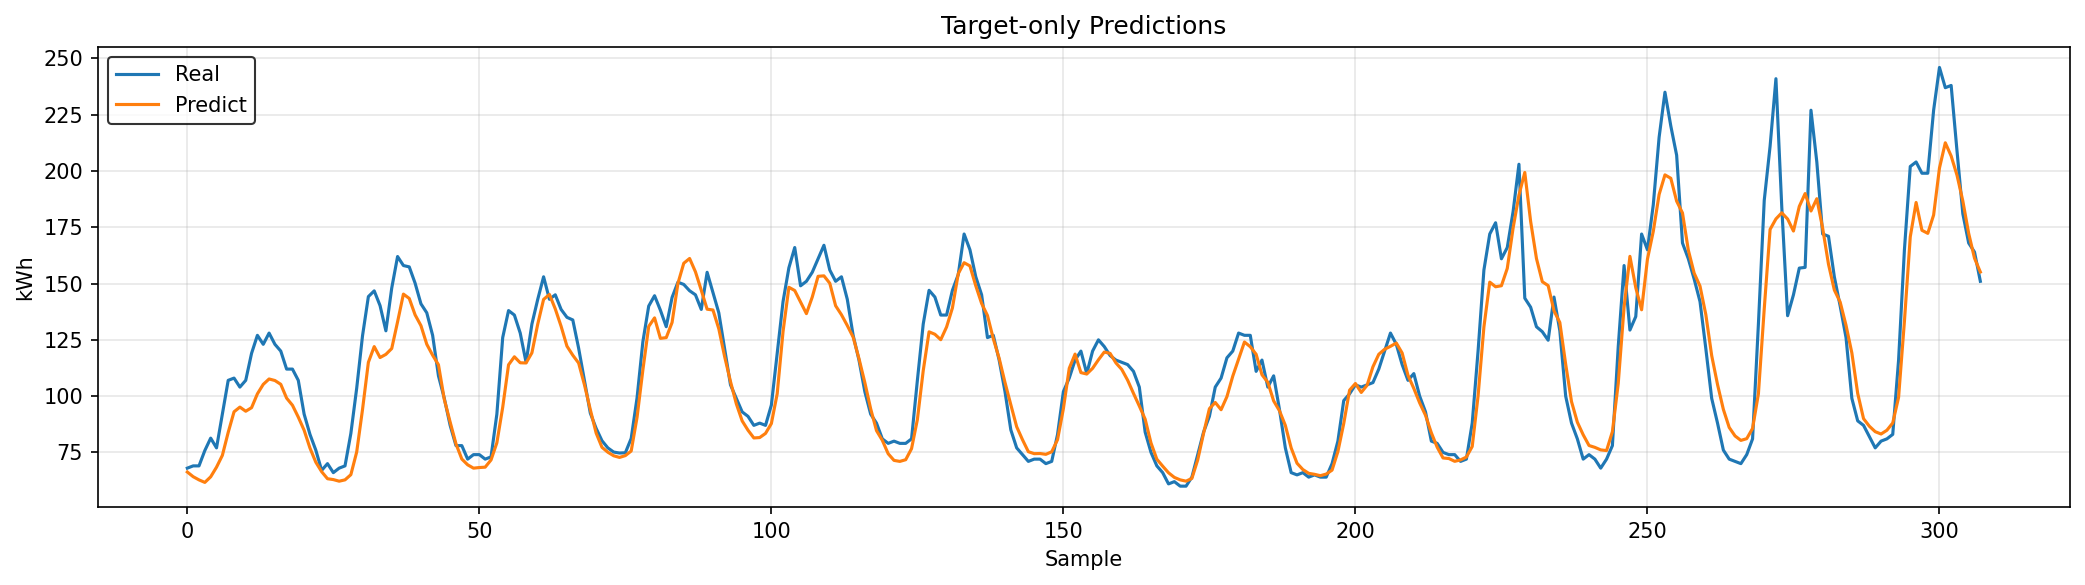

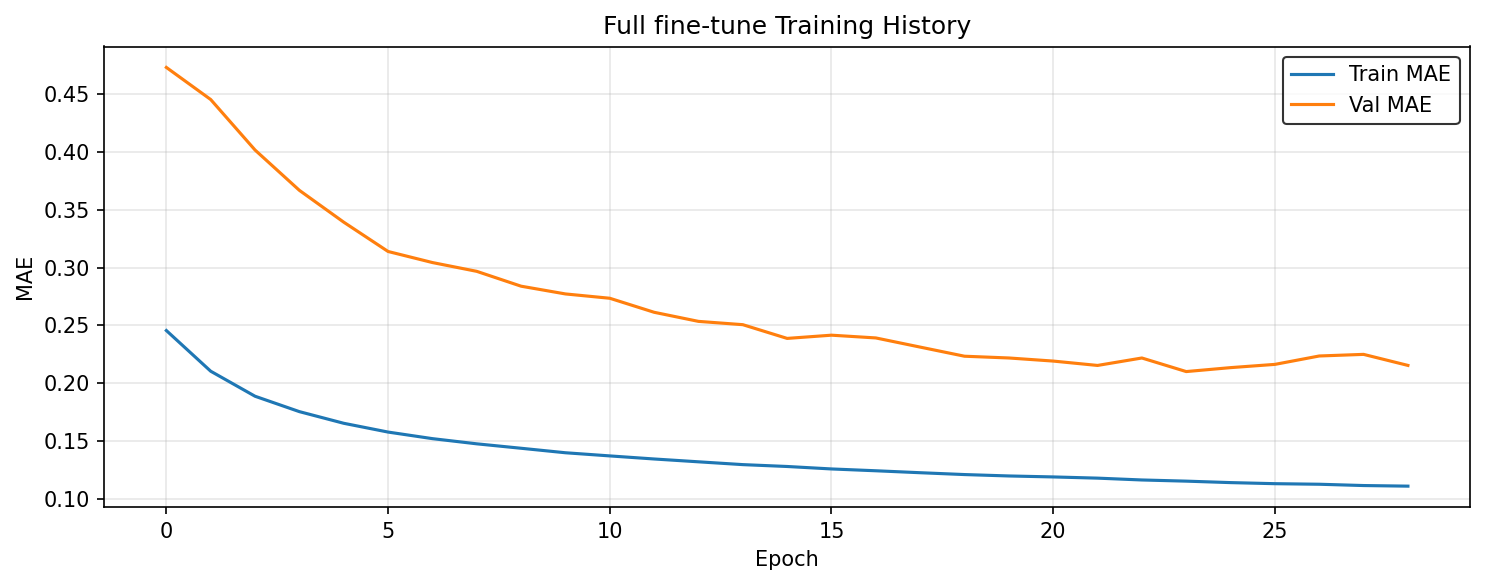

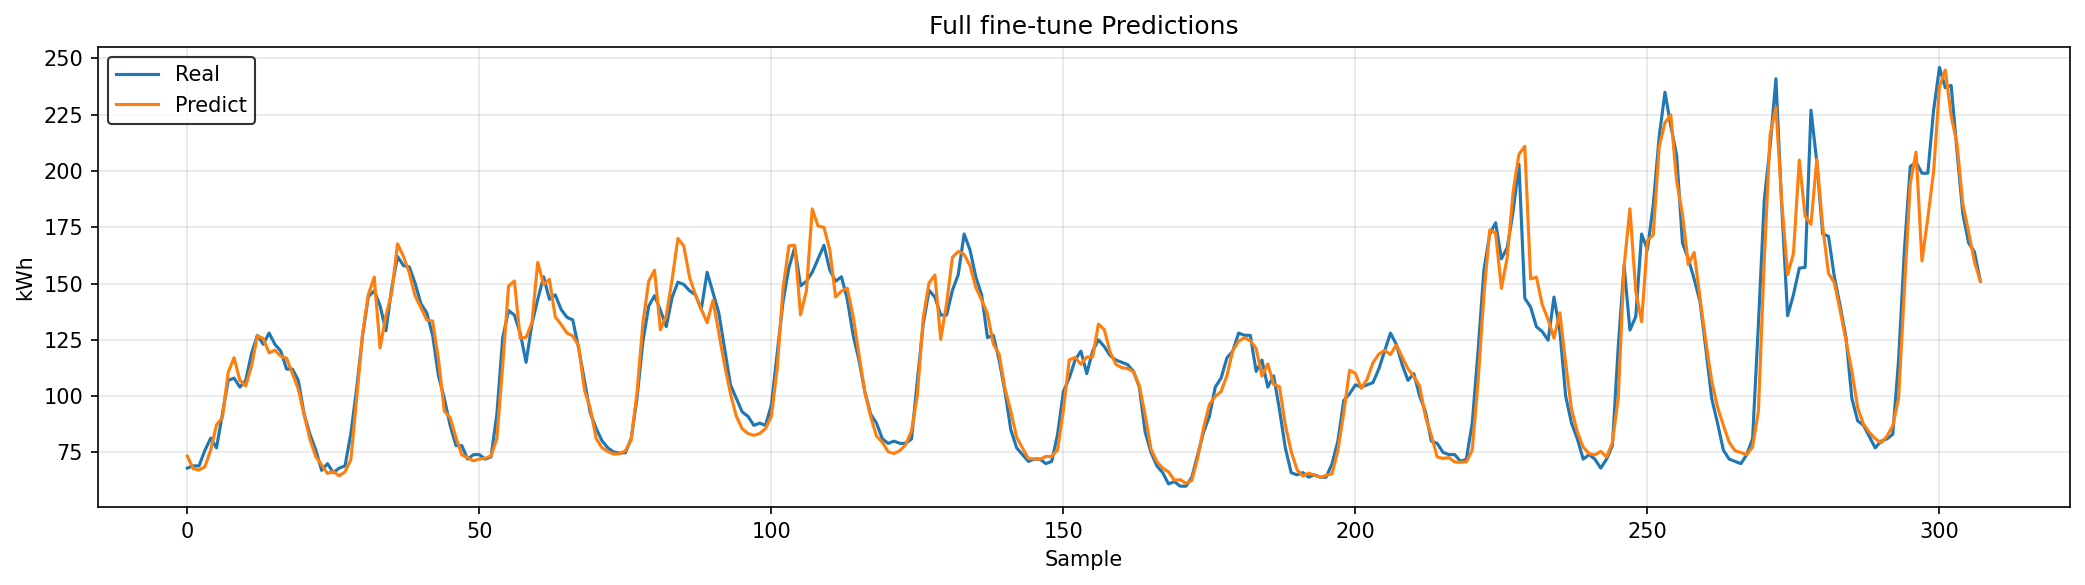

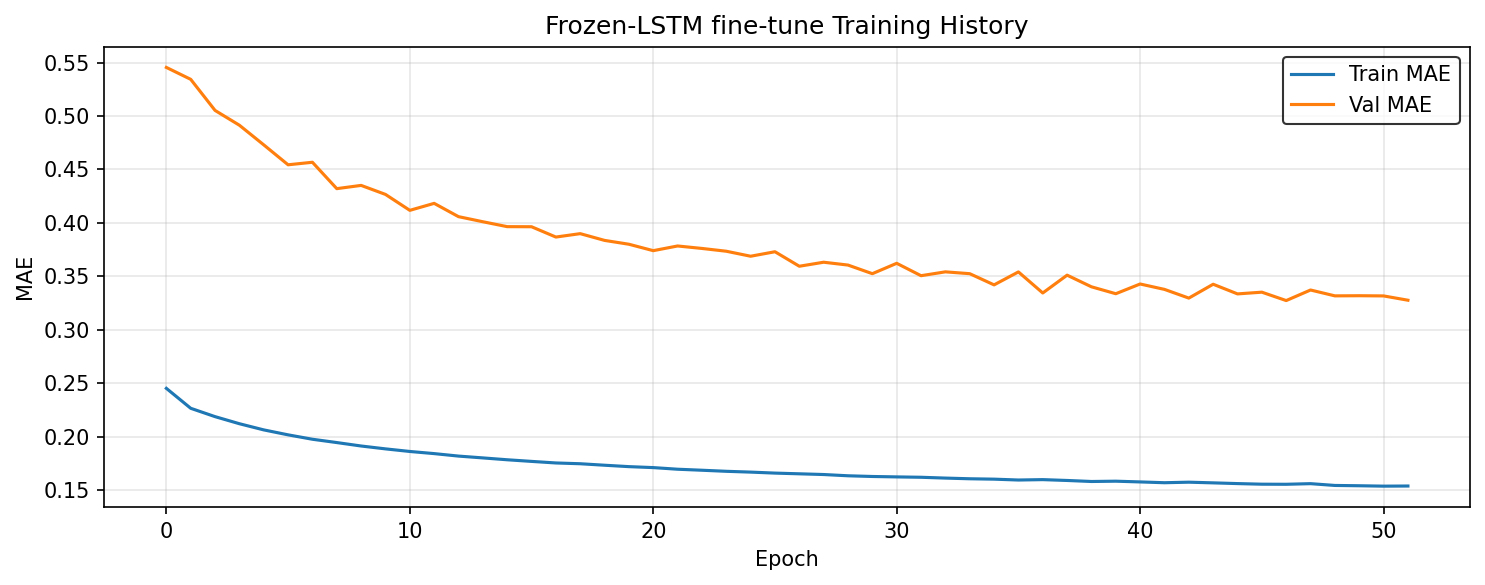

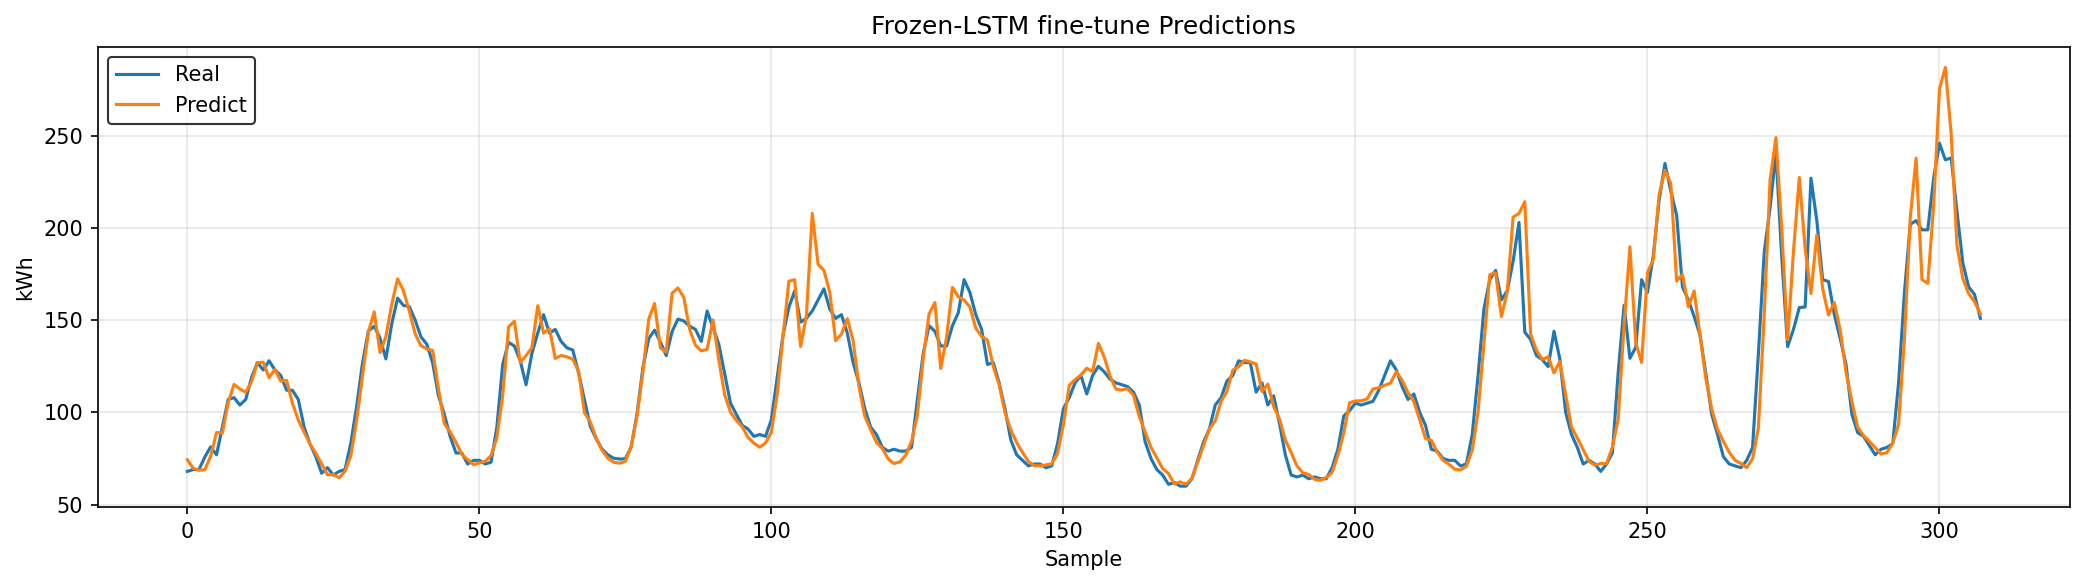

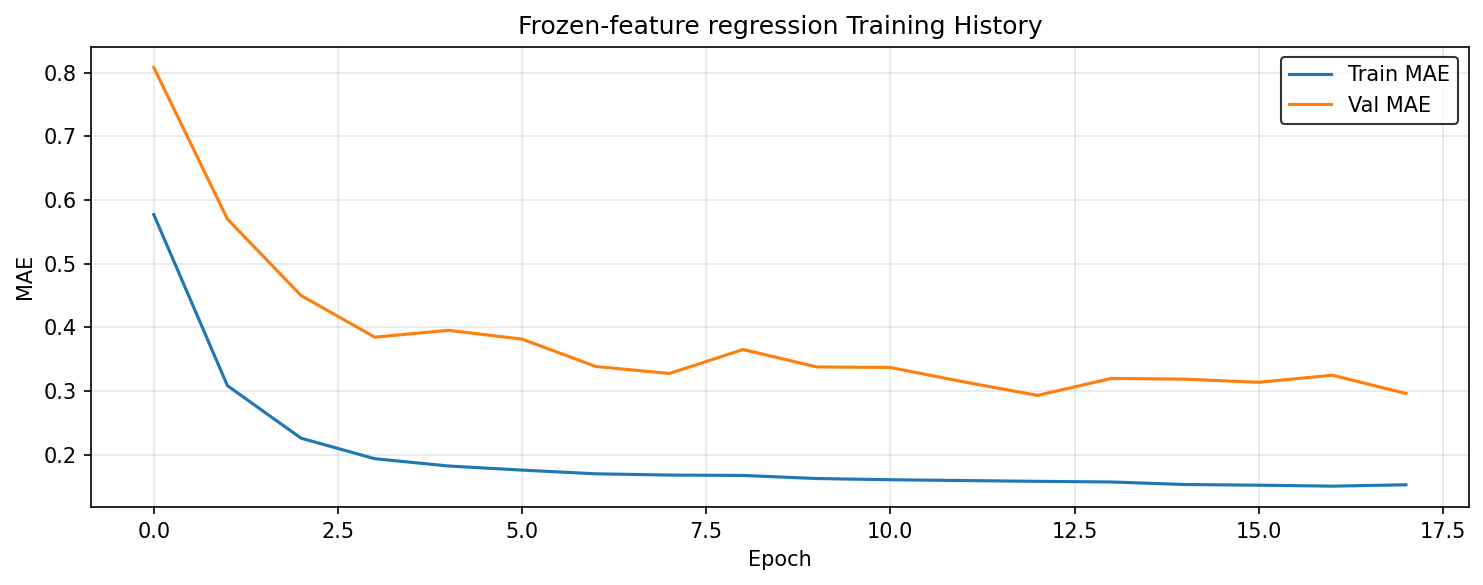

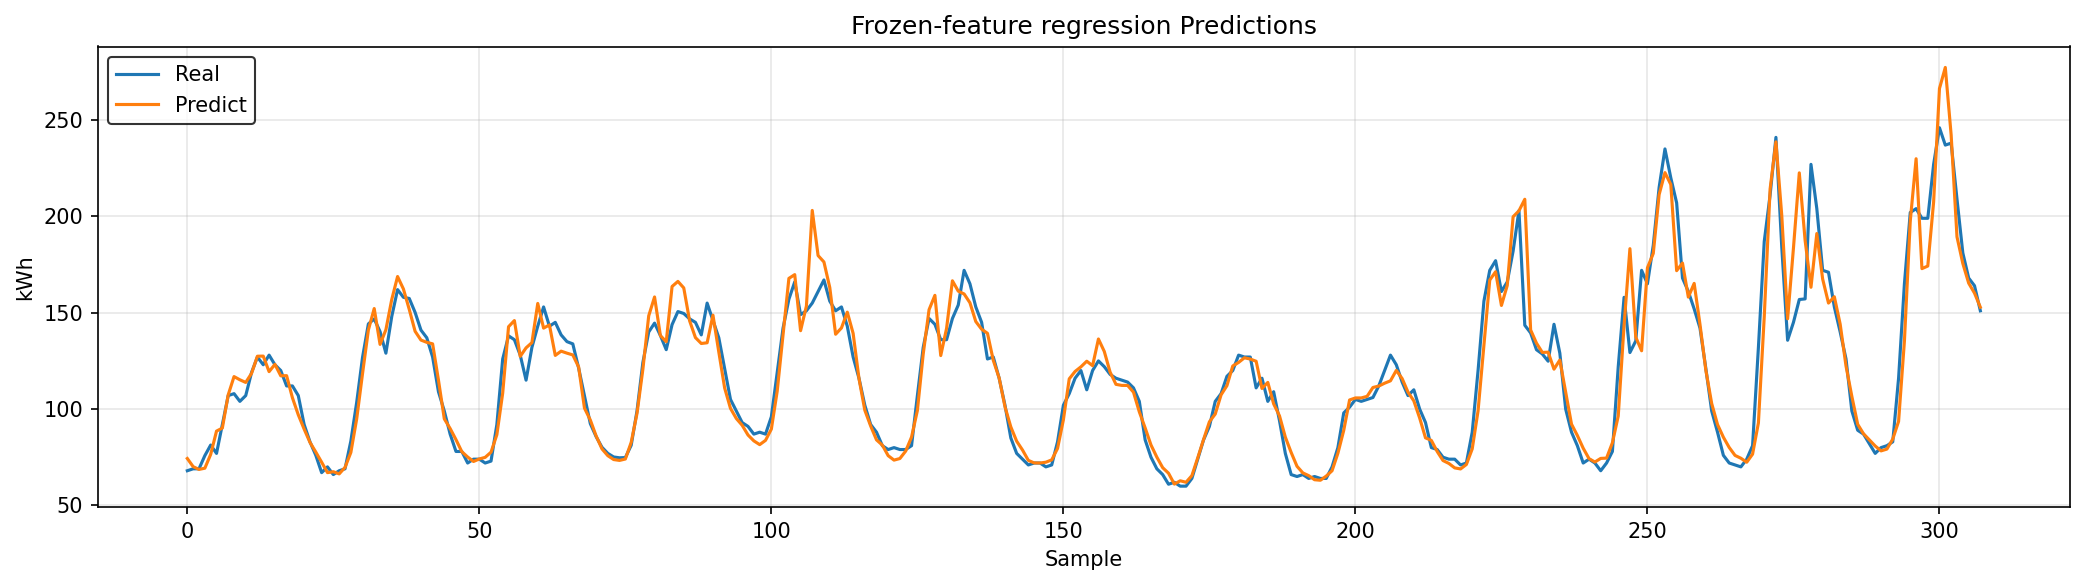

 >> 在 seed=21 下完成训练


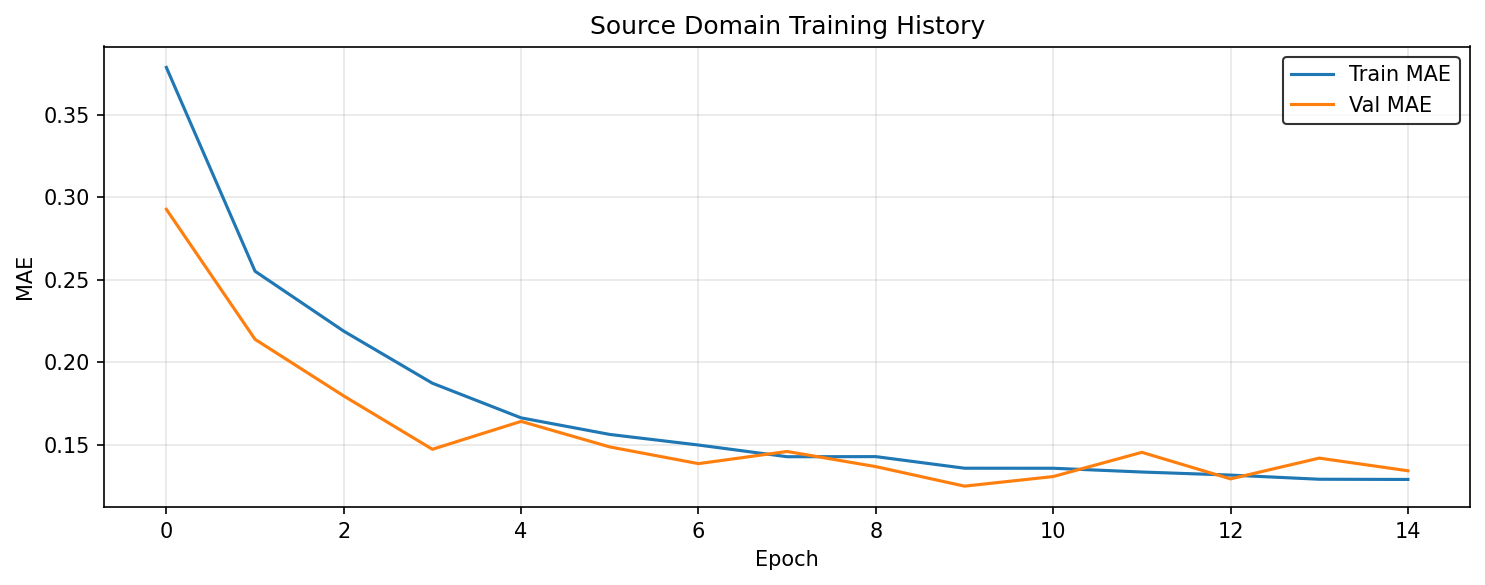

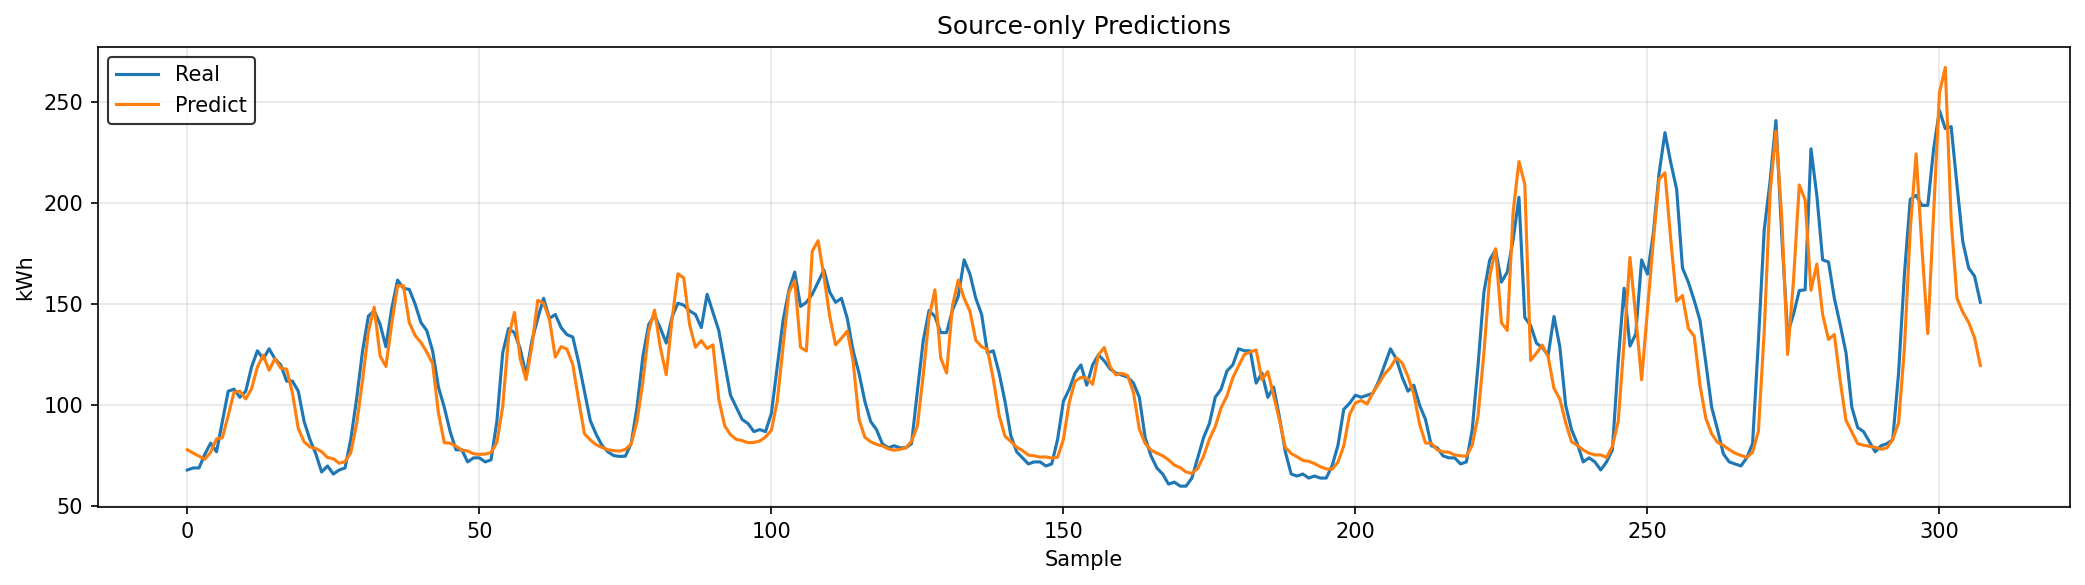

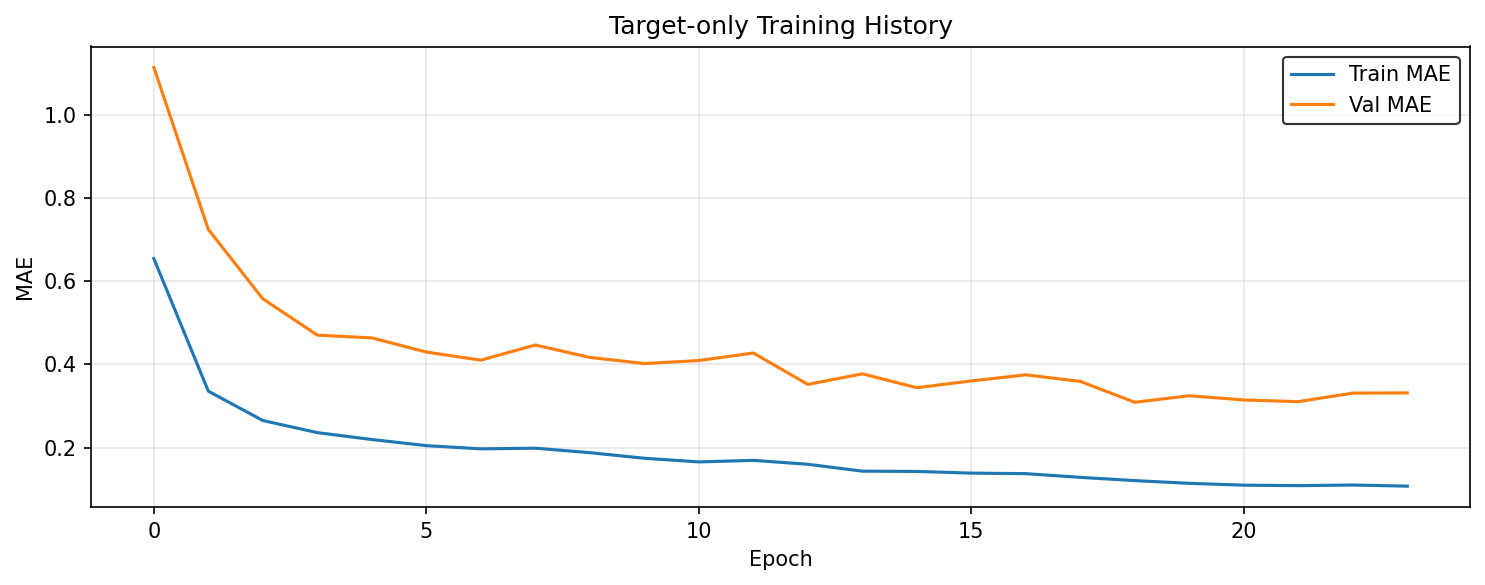

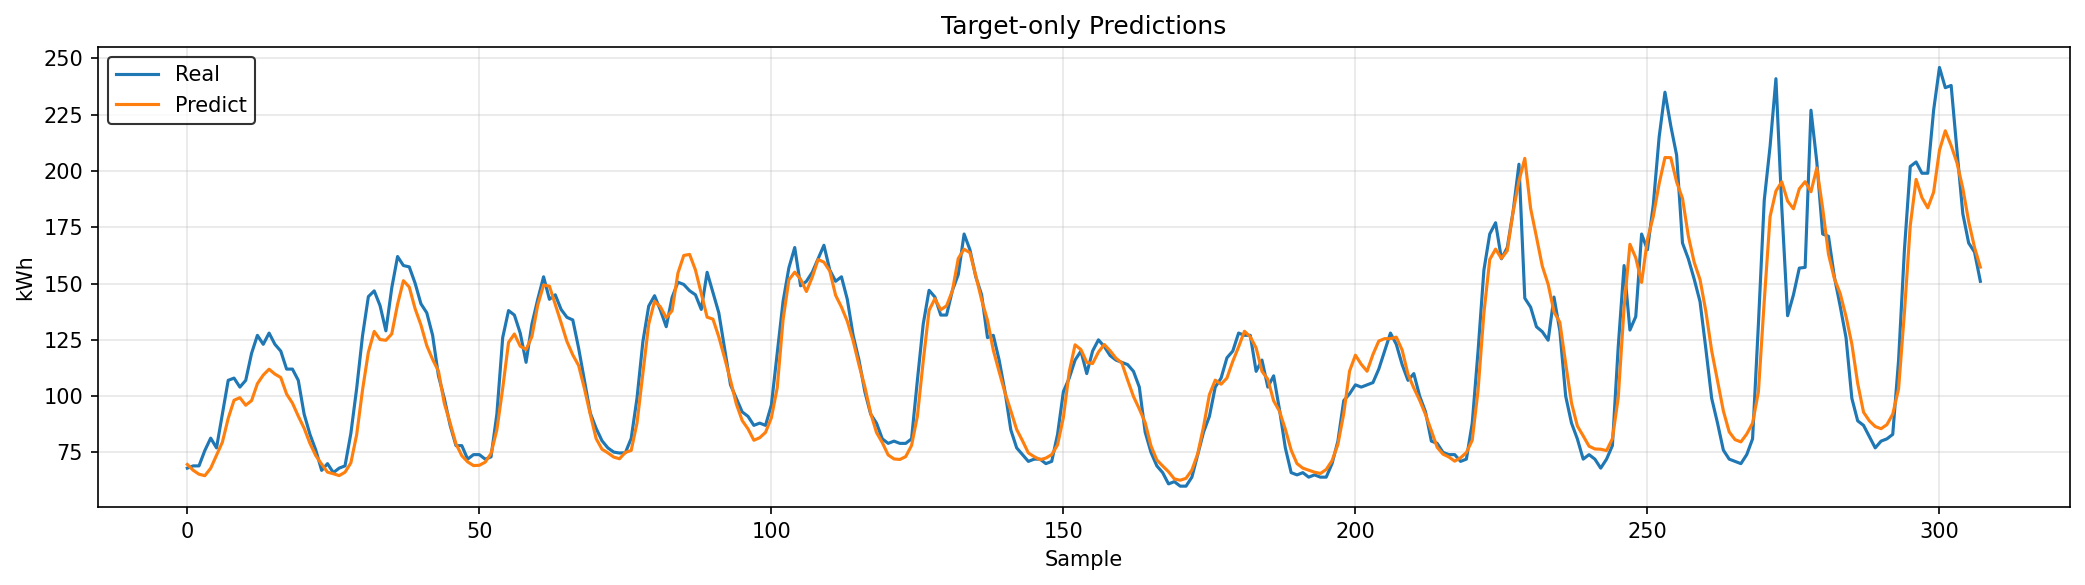

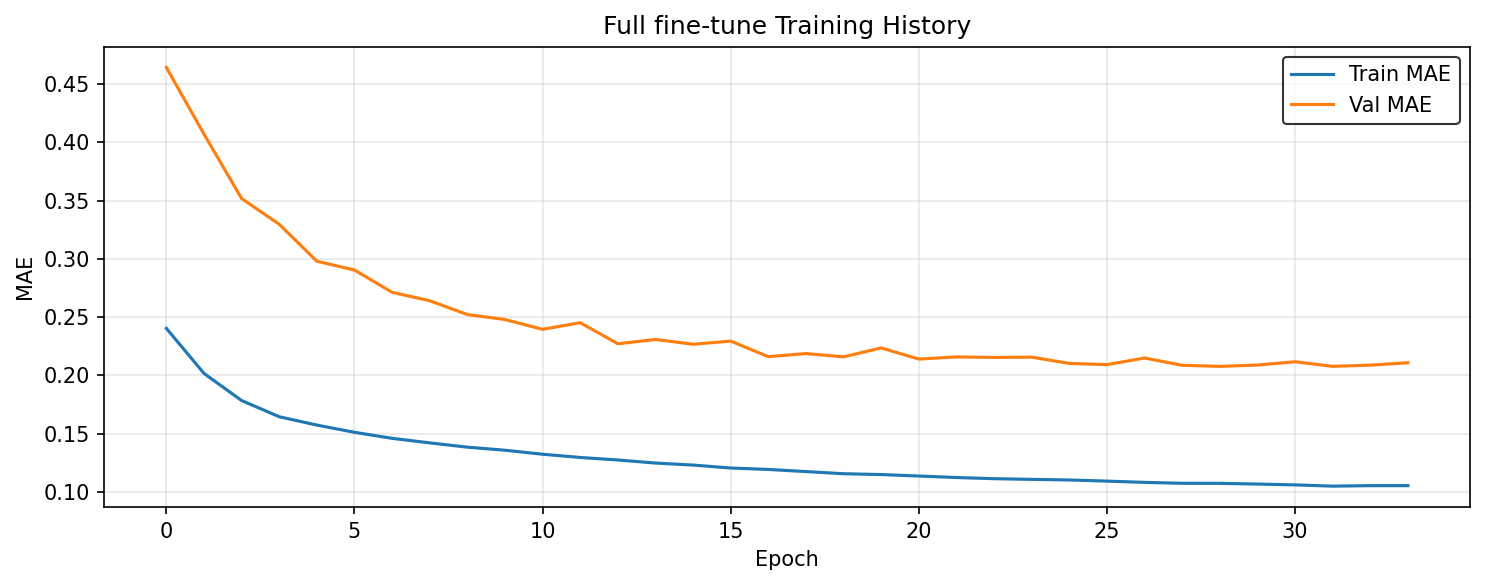

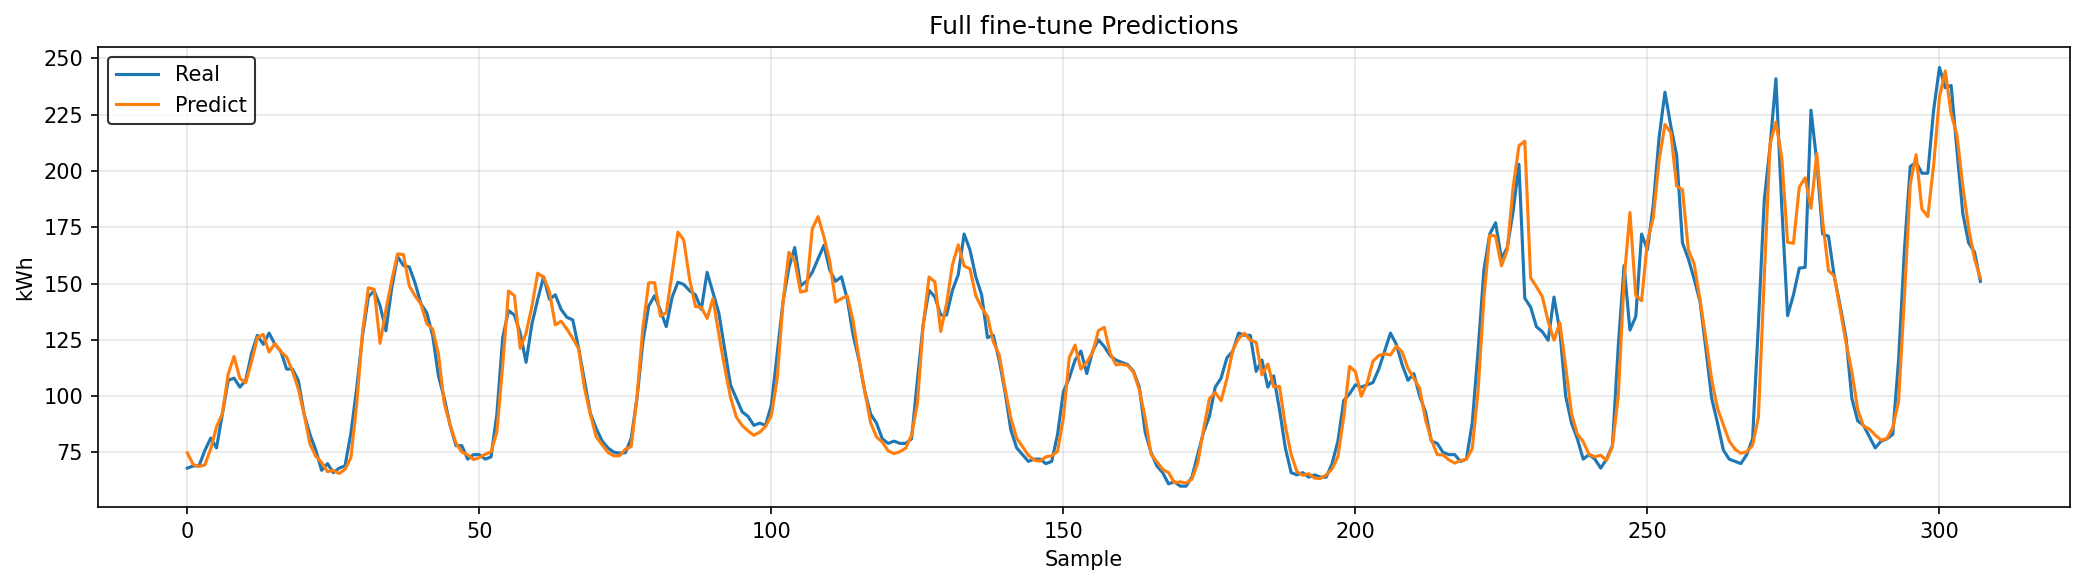

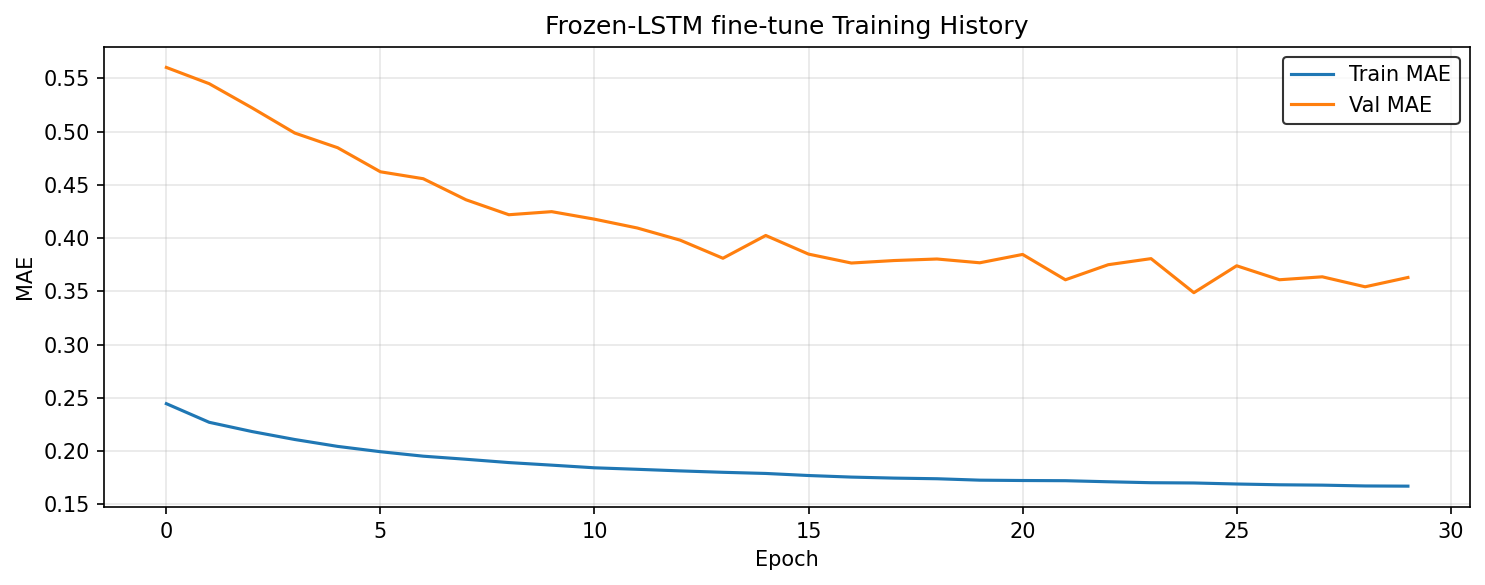

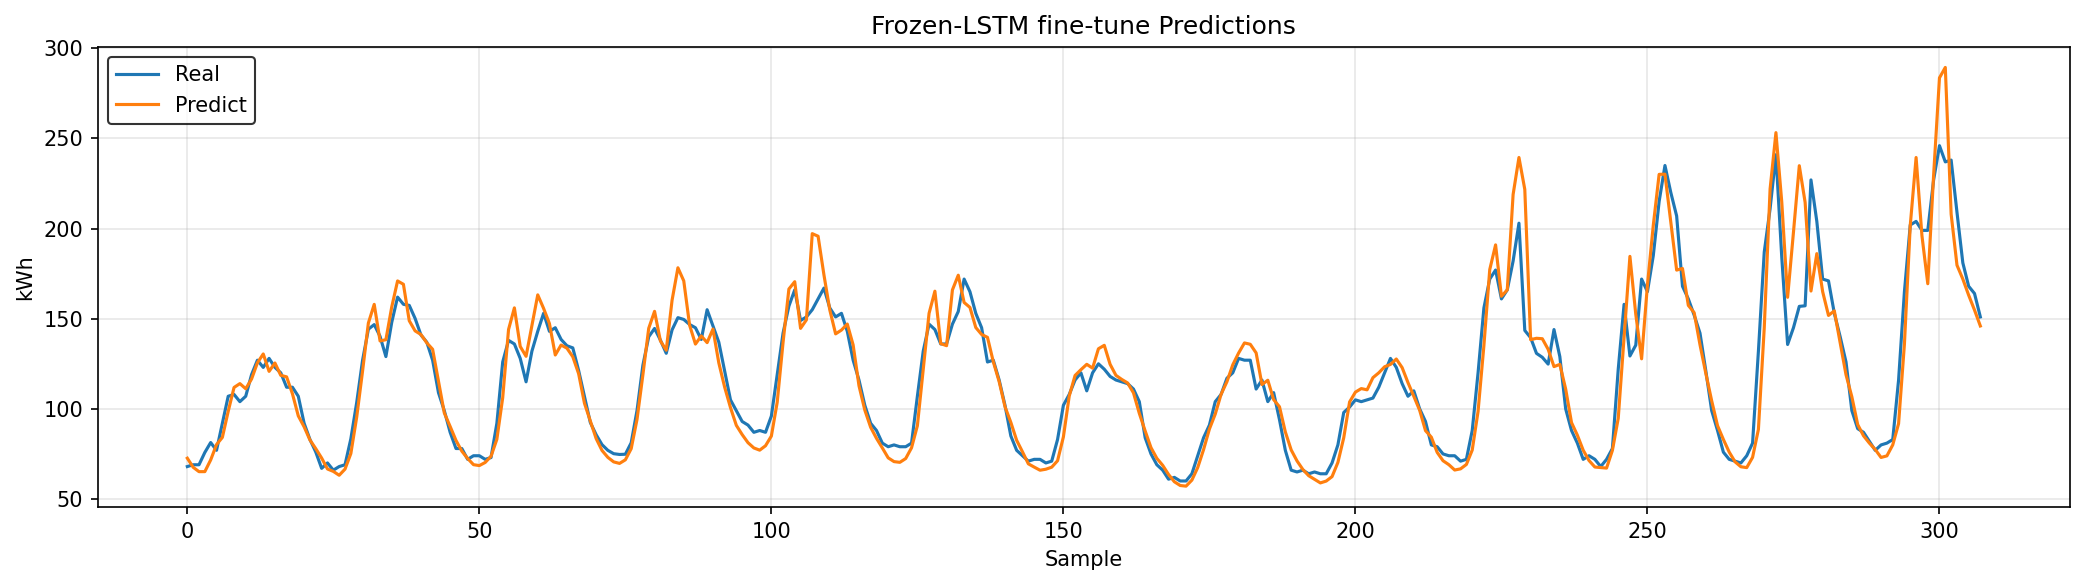

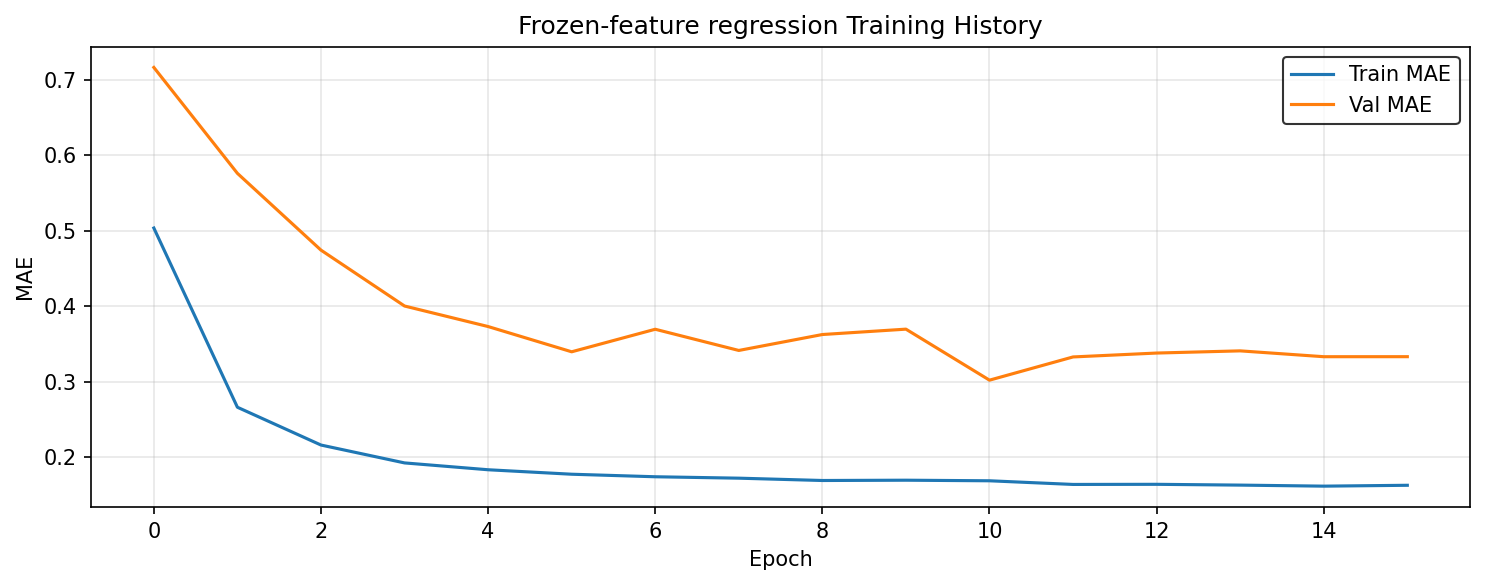

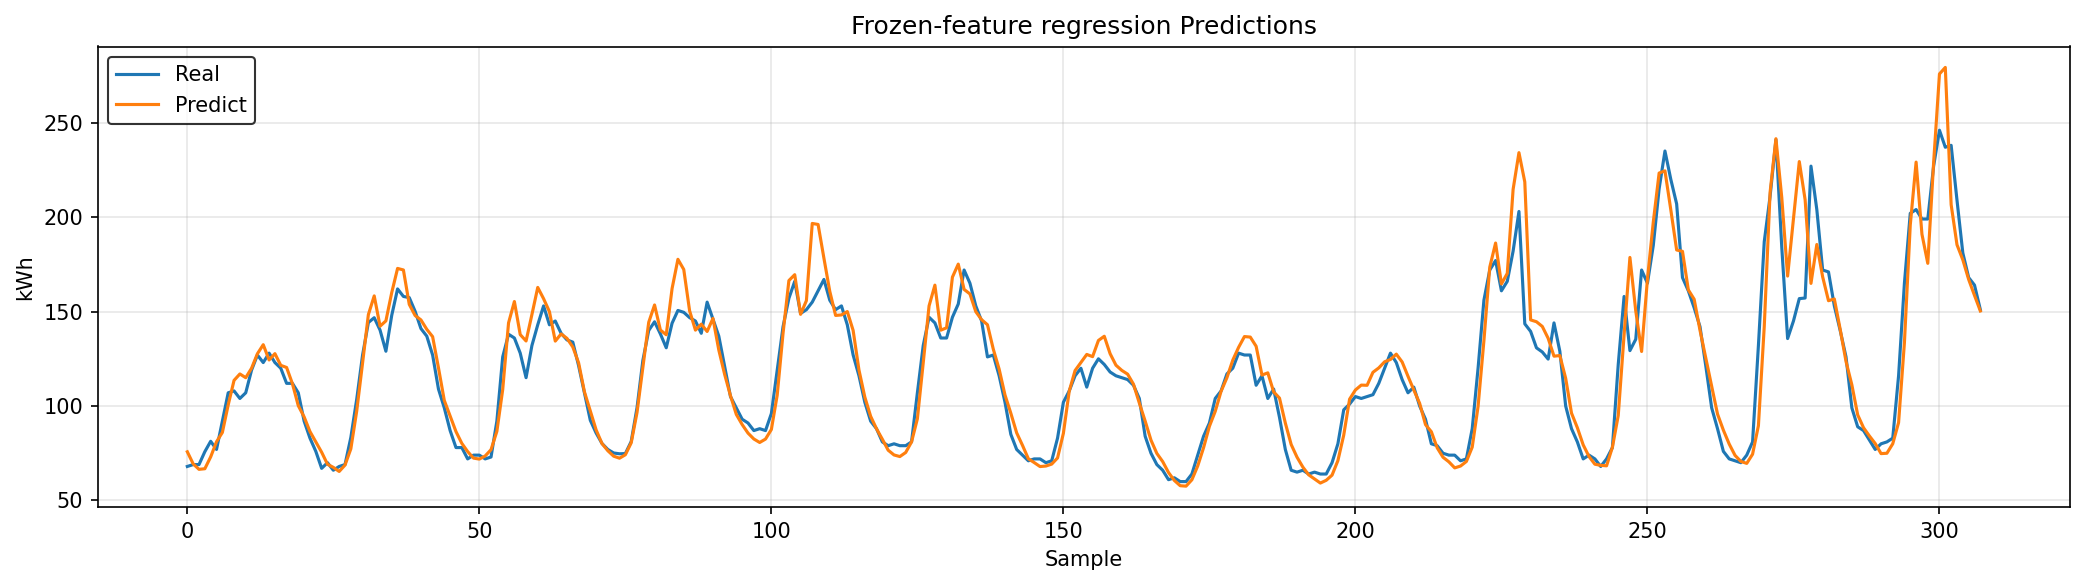

 >> 在 seed=84 下完成训练


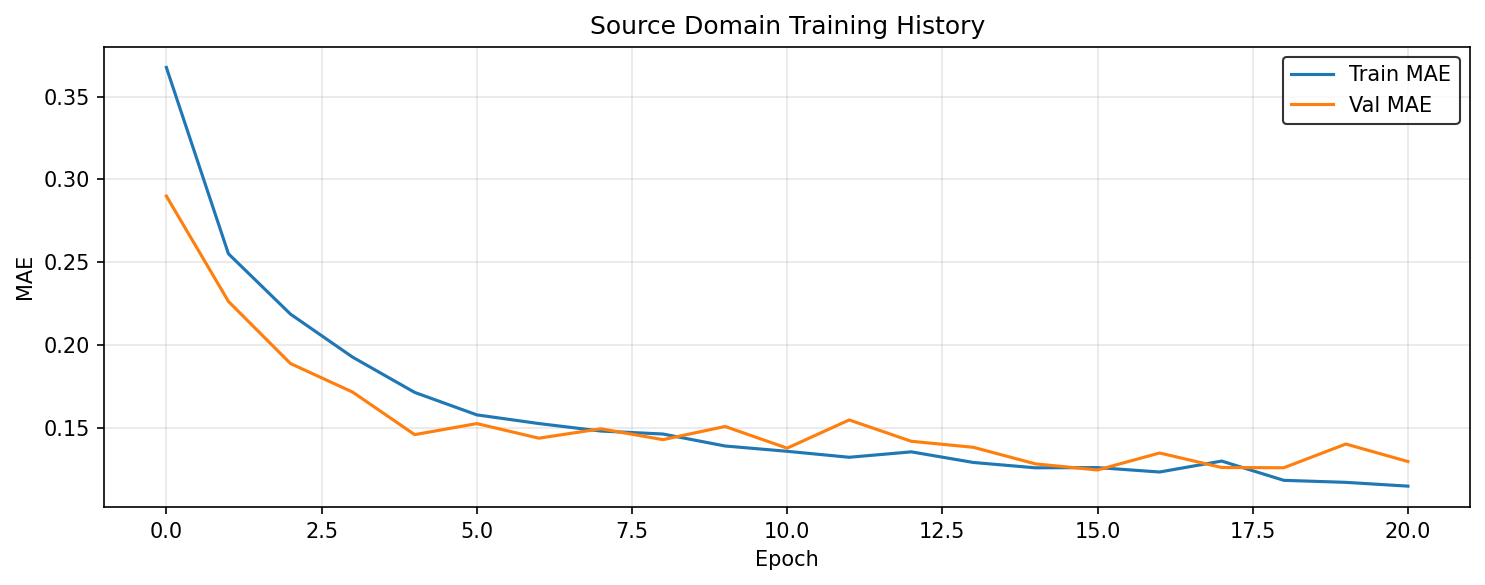

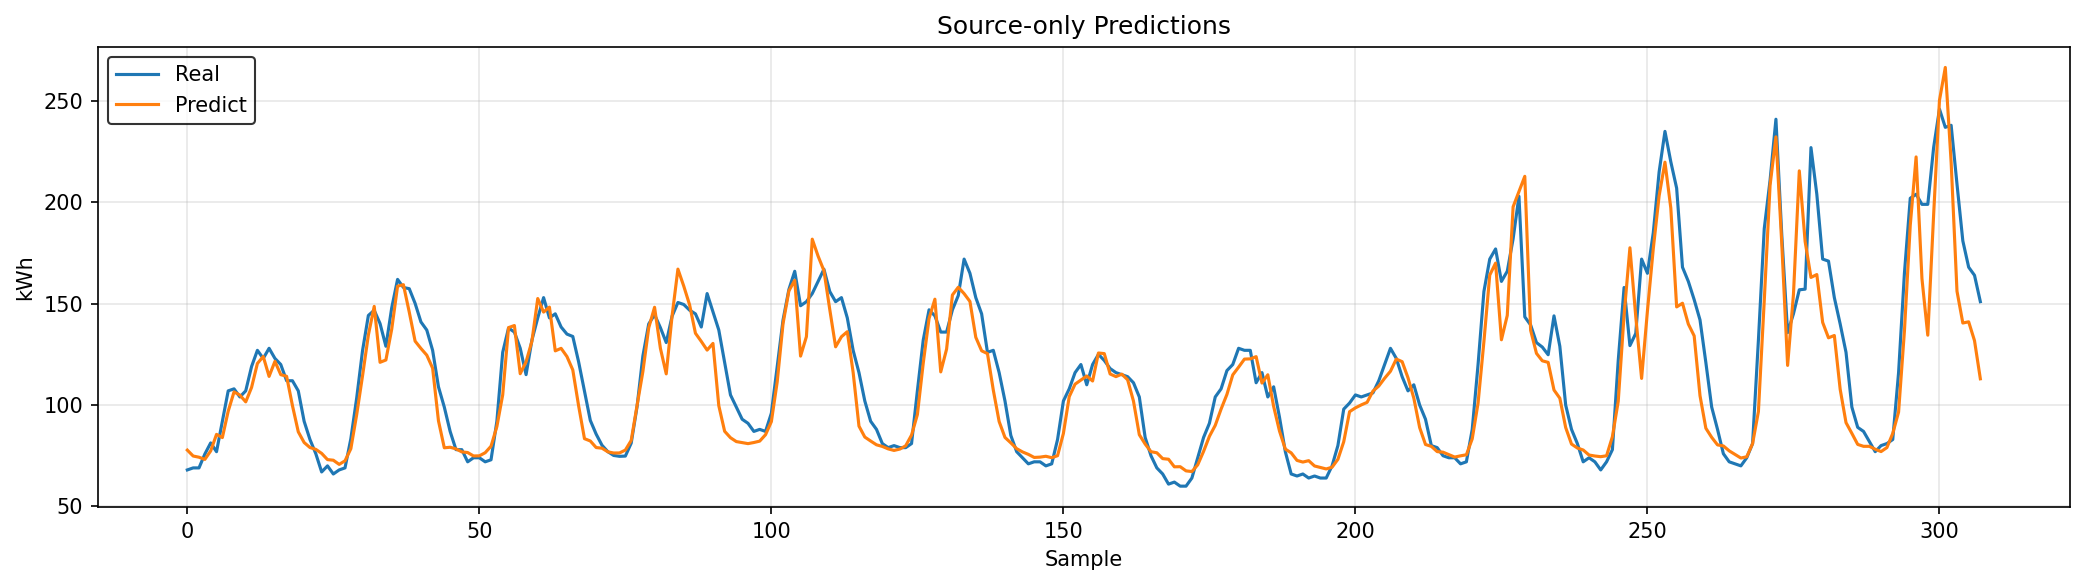

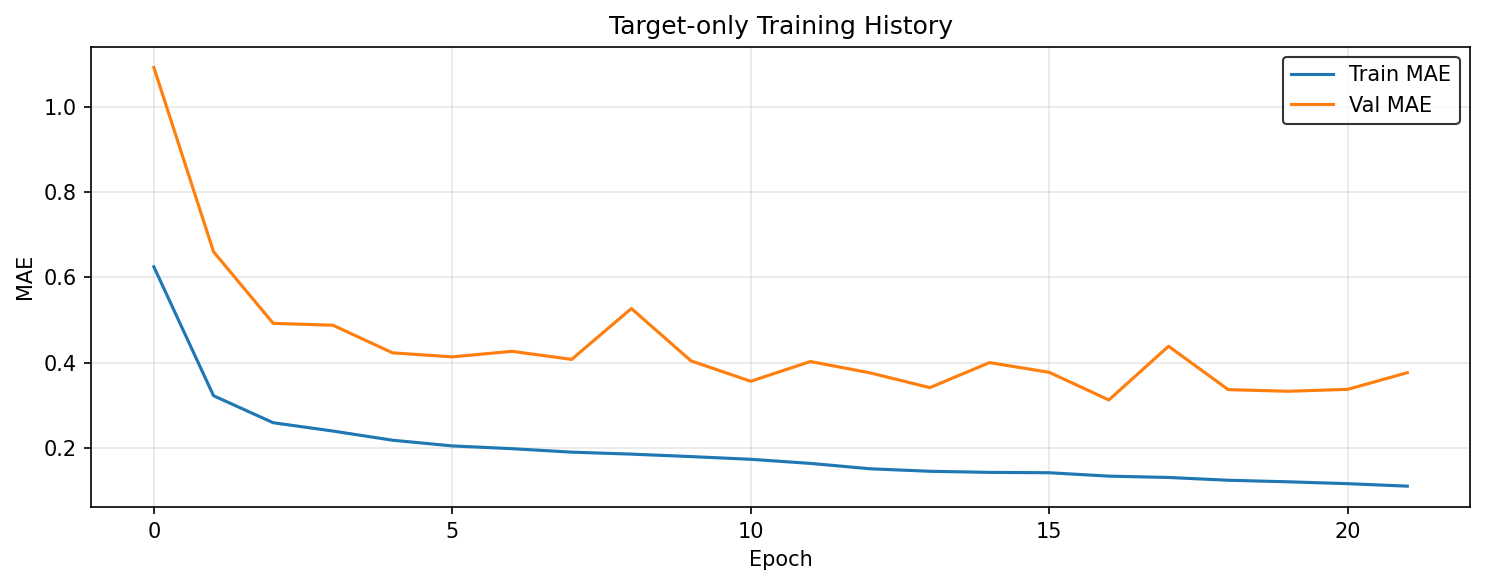

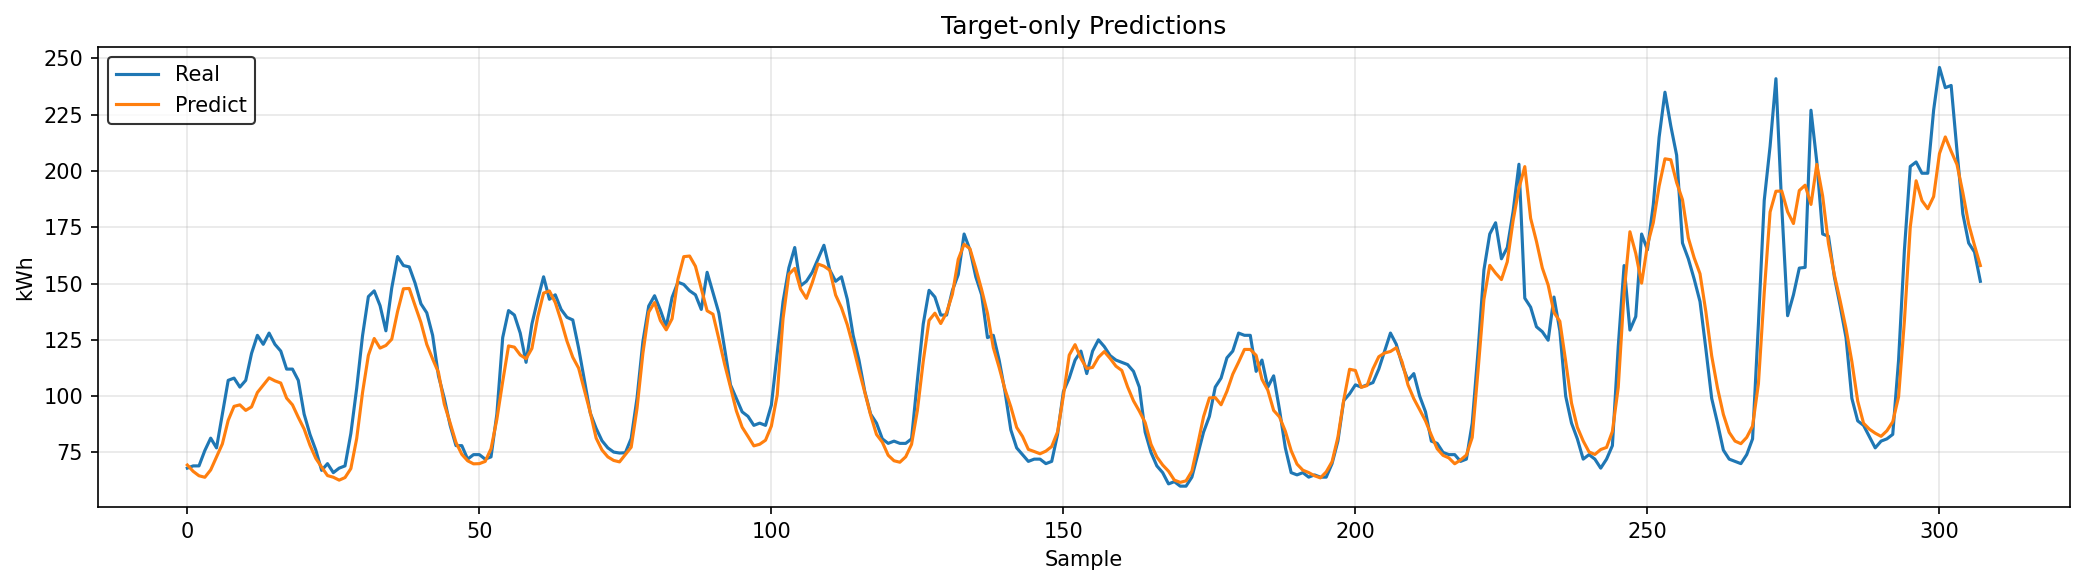

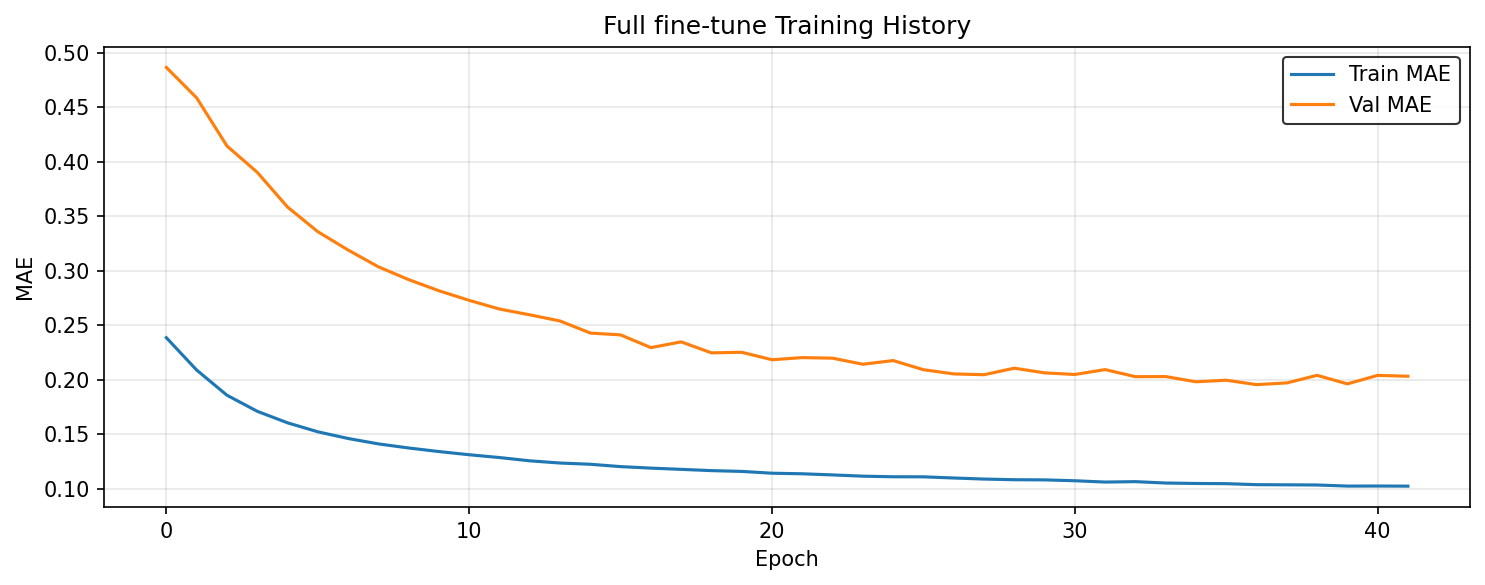

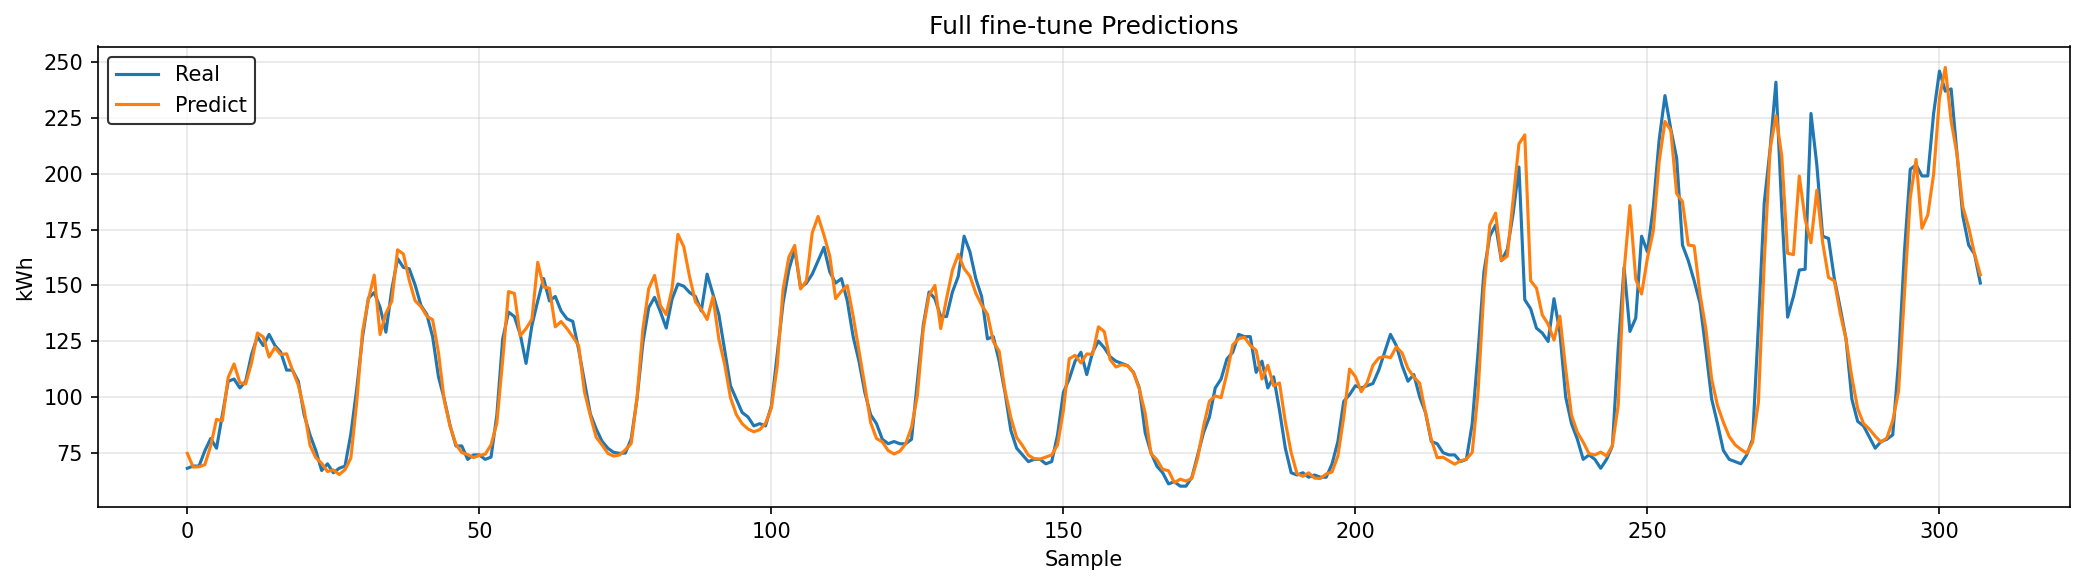

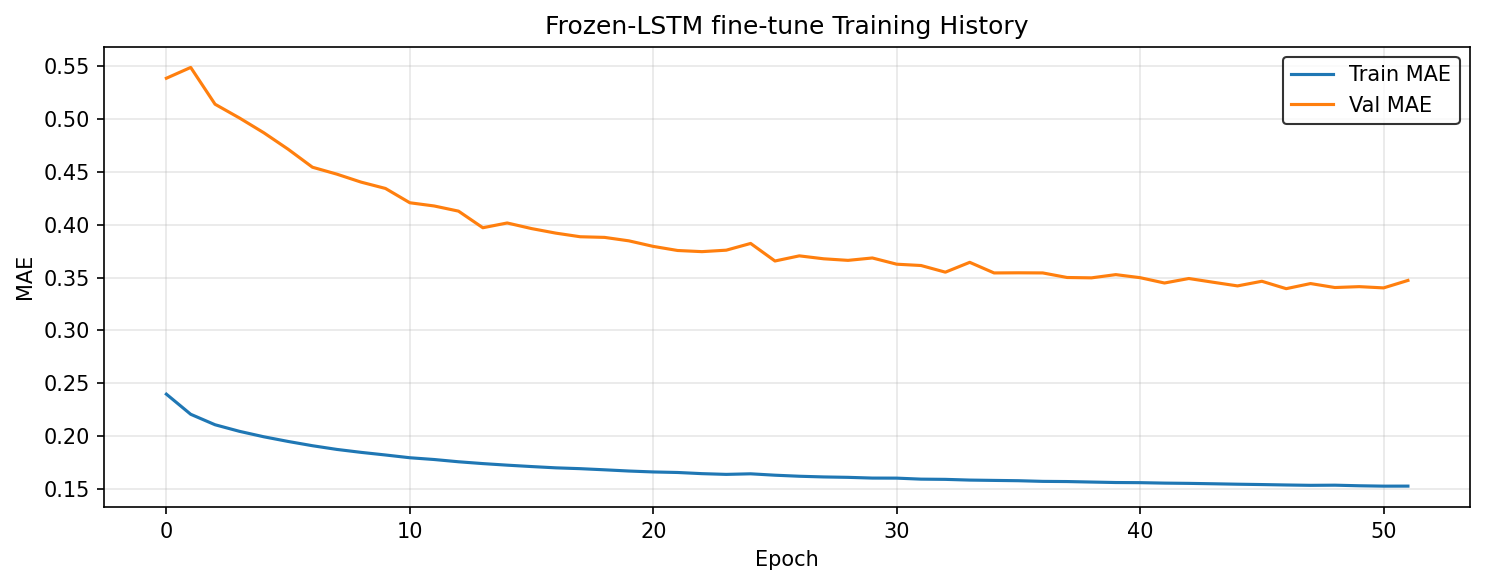

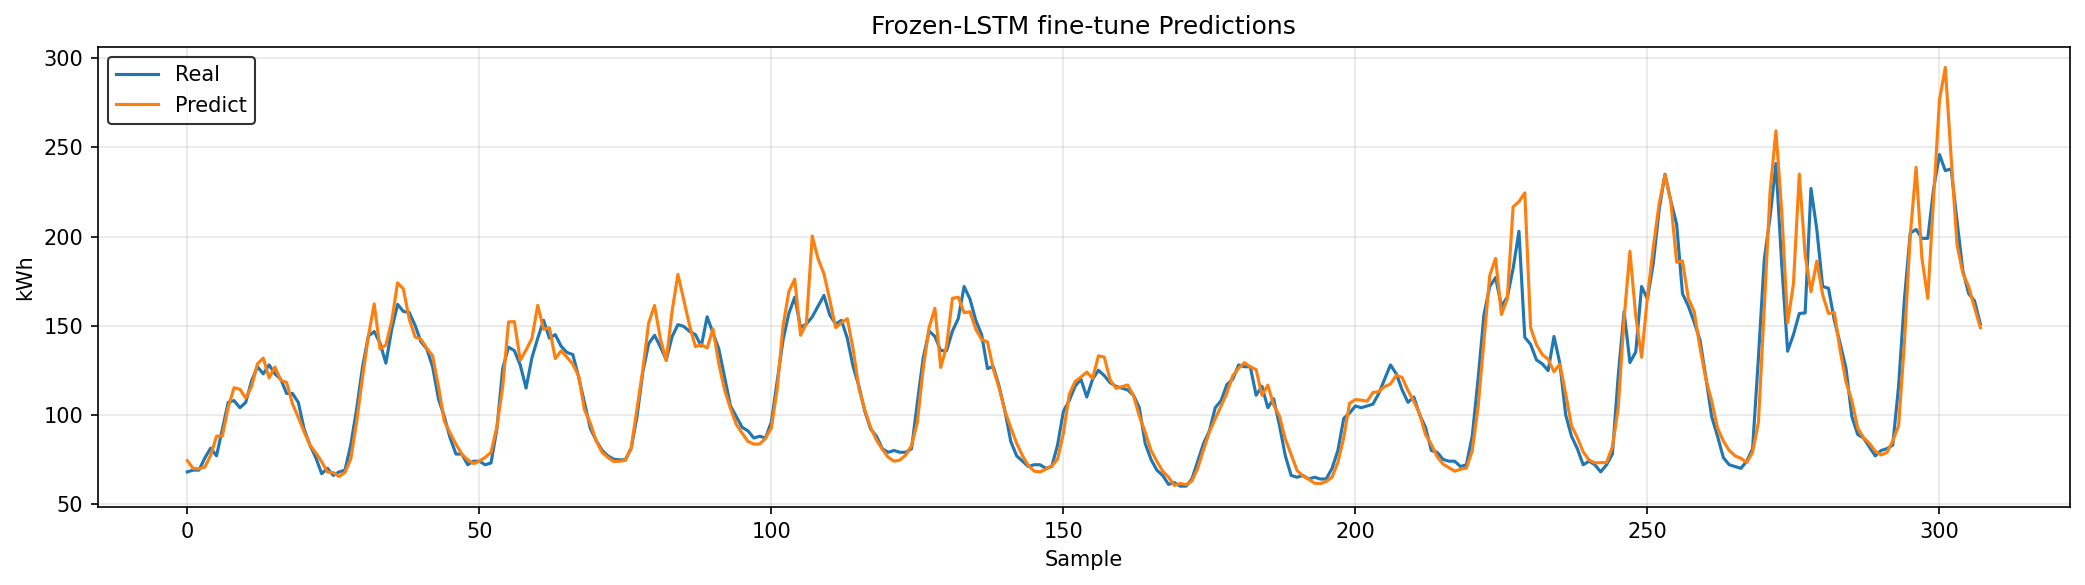

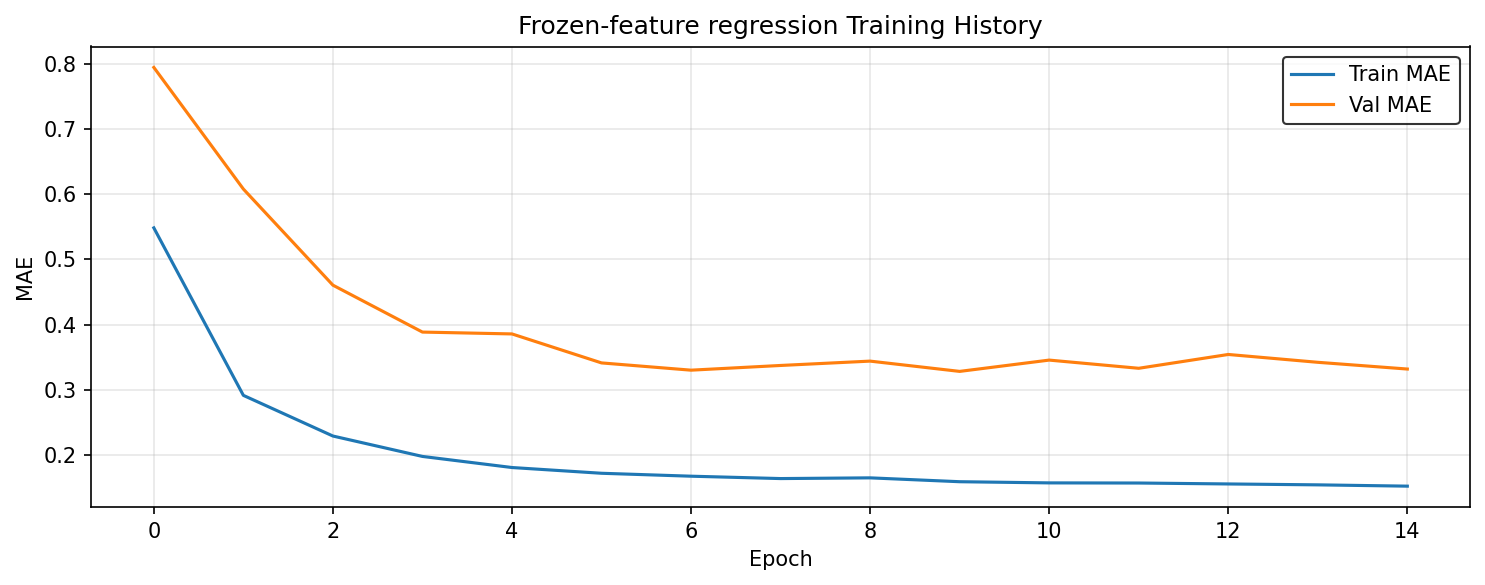

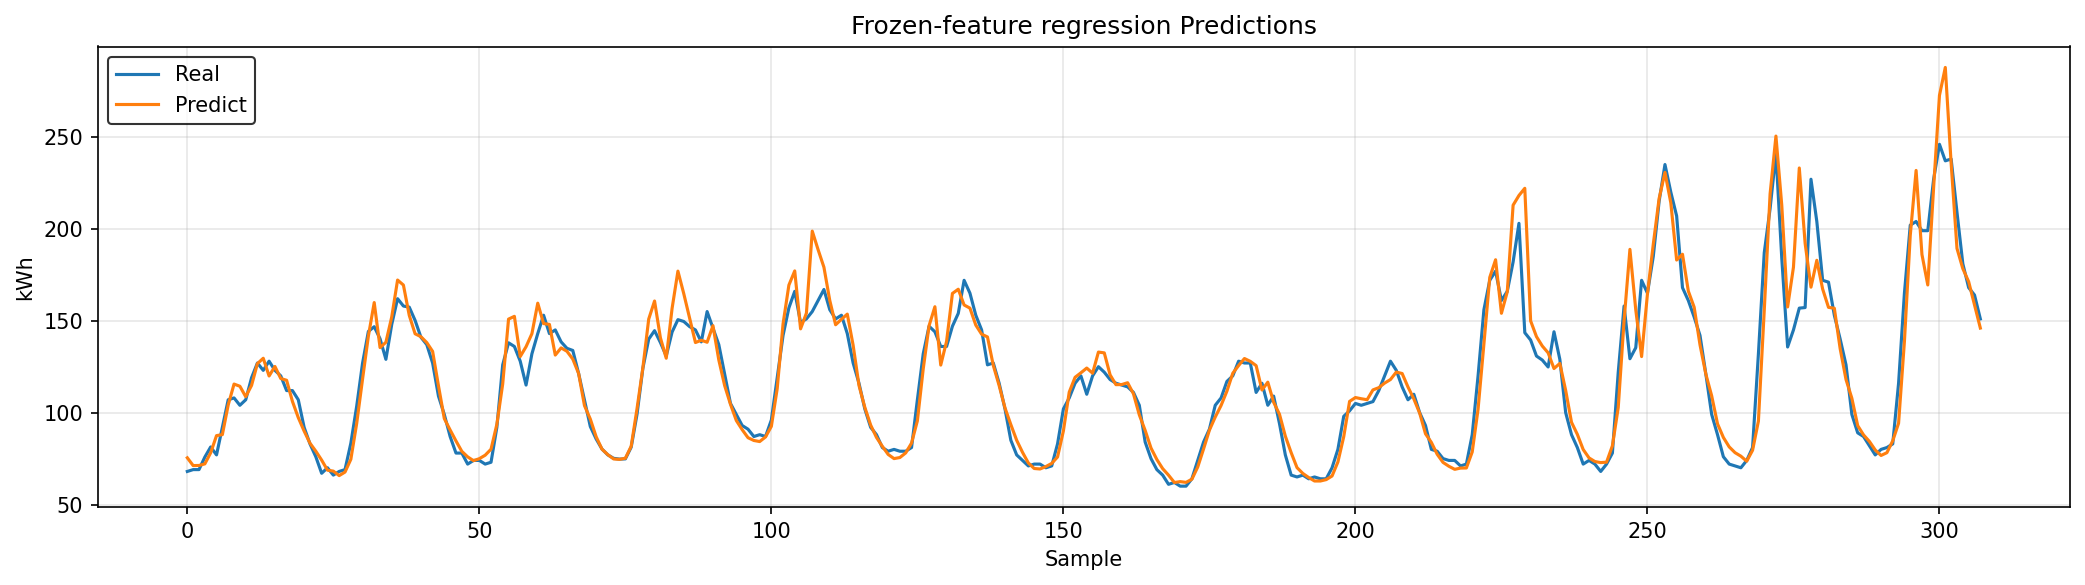

 >> 在 seed=2024 下完成训练


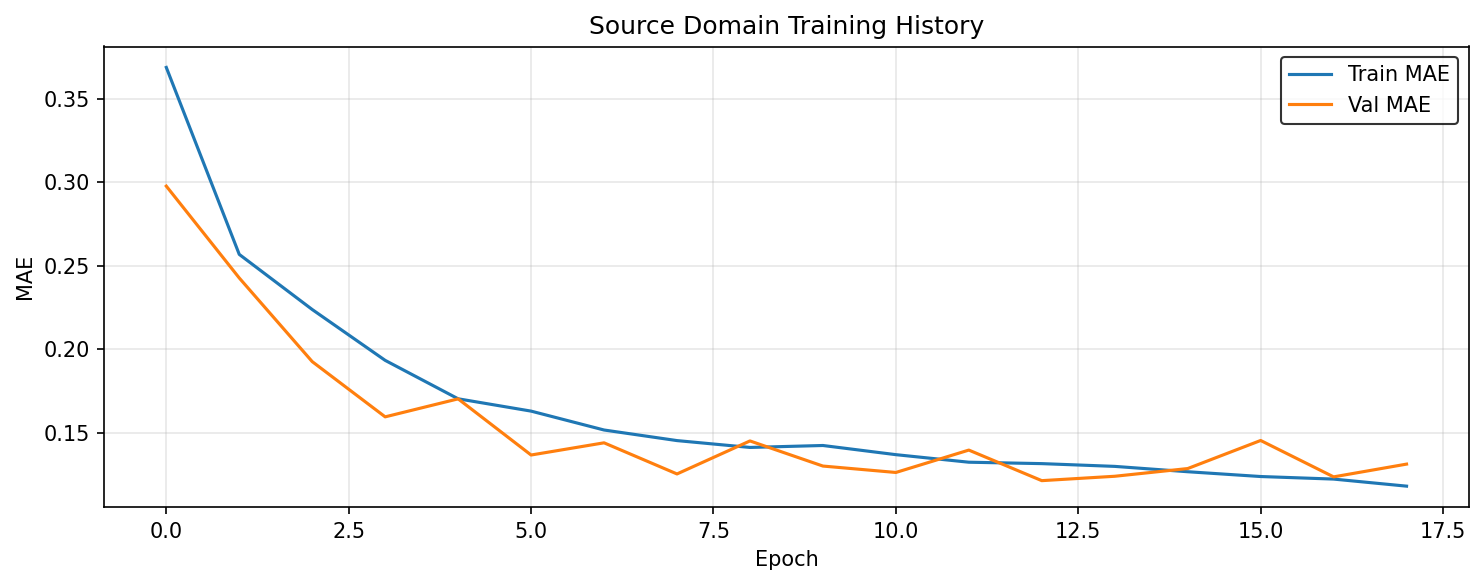

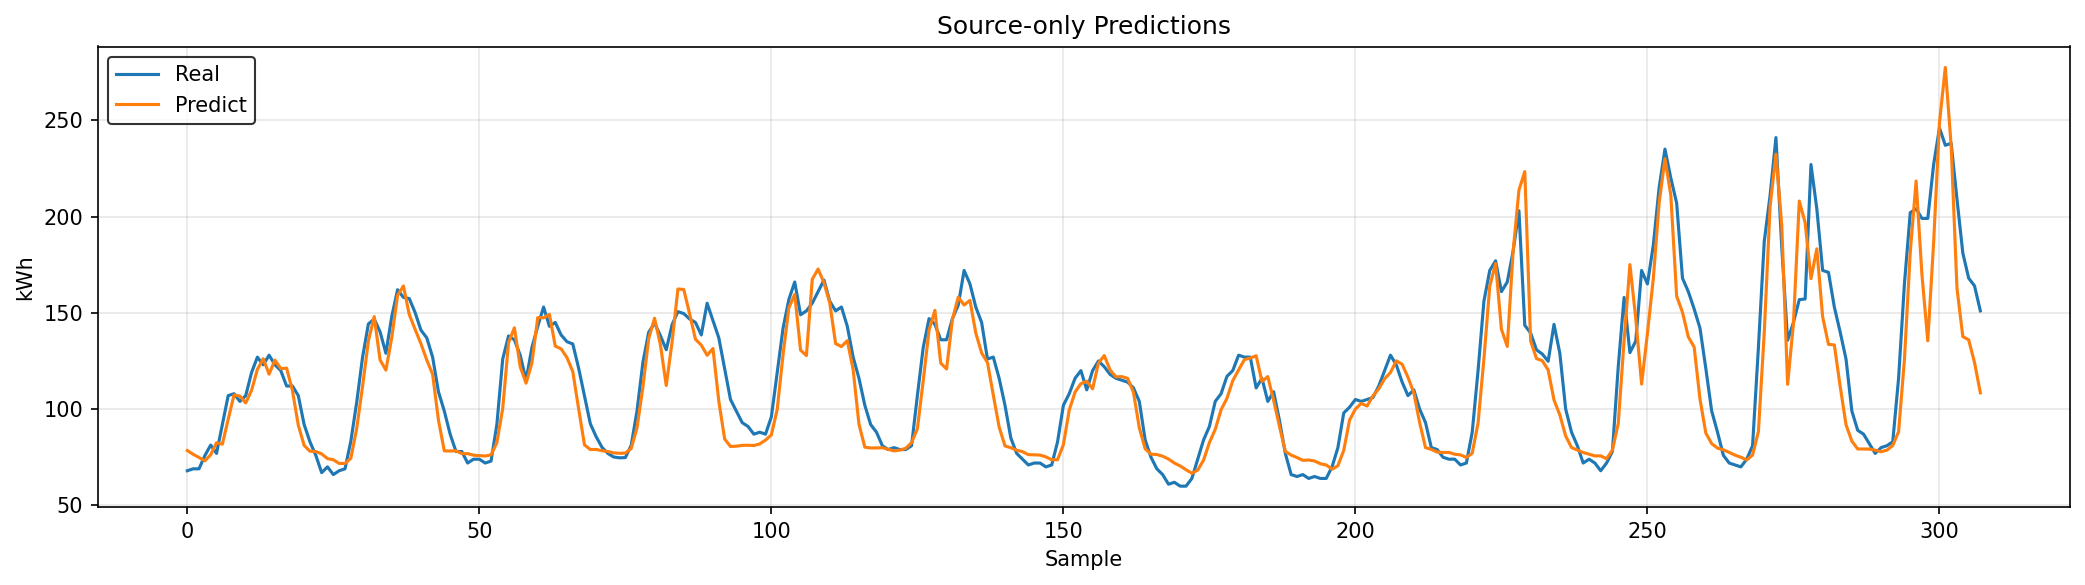

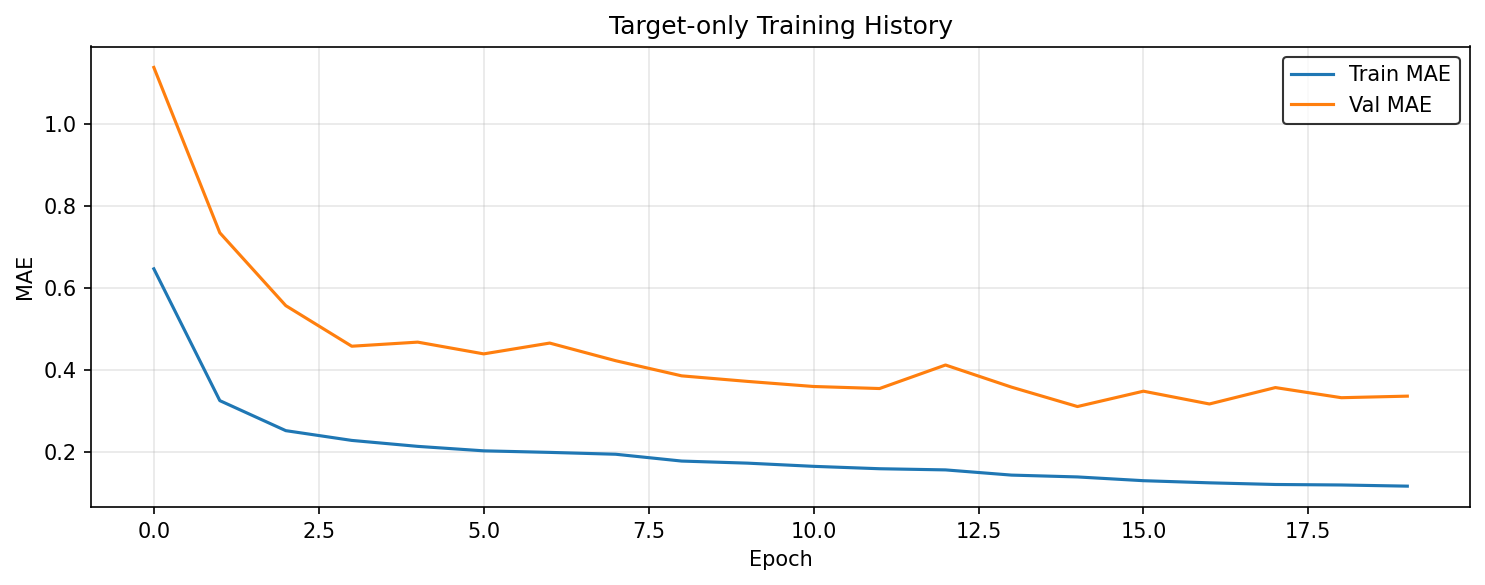

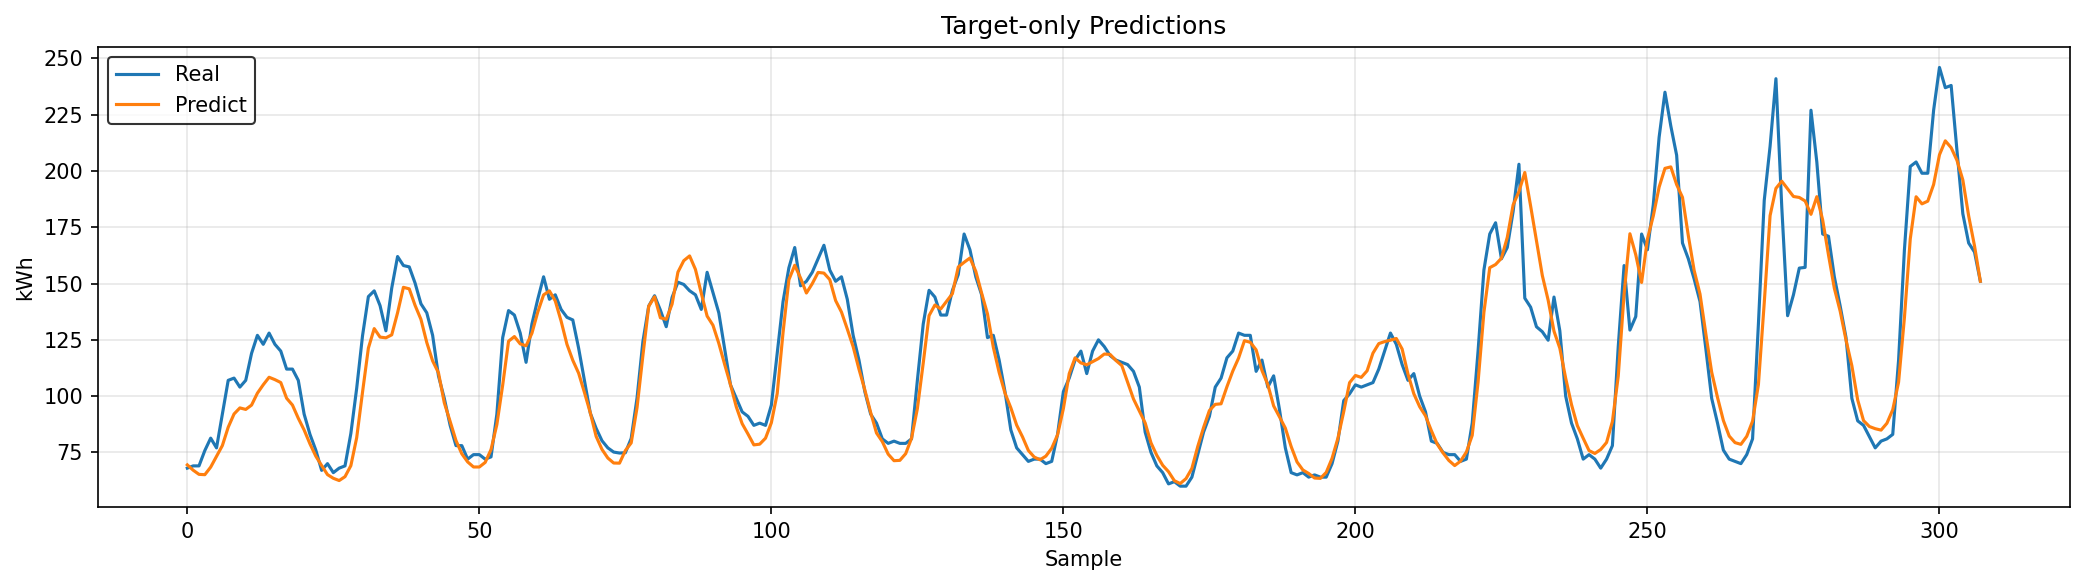

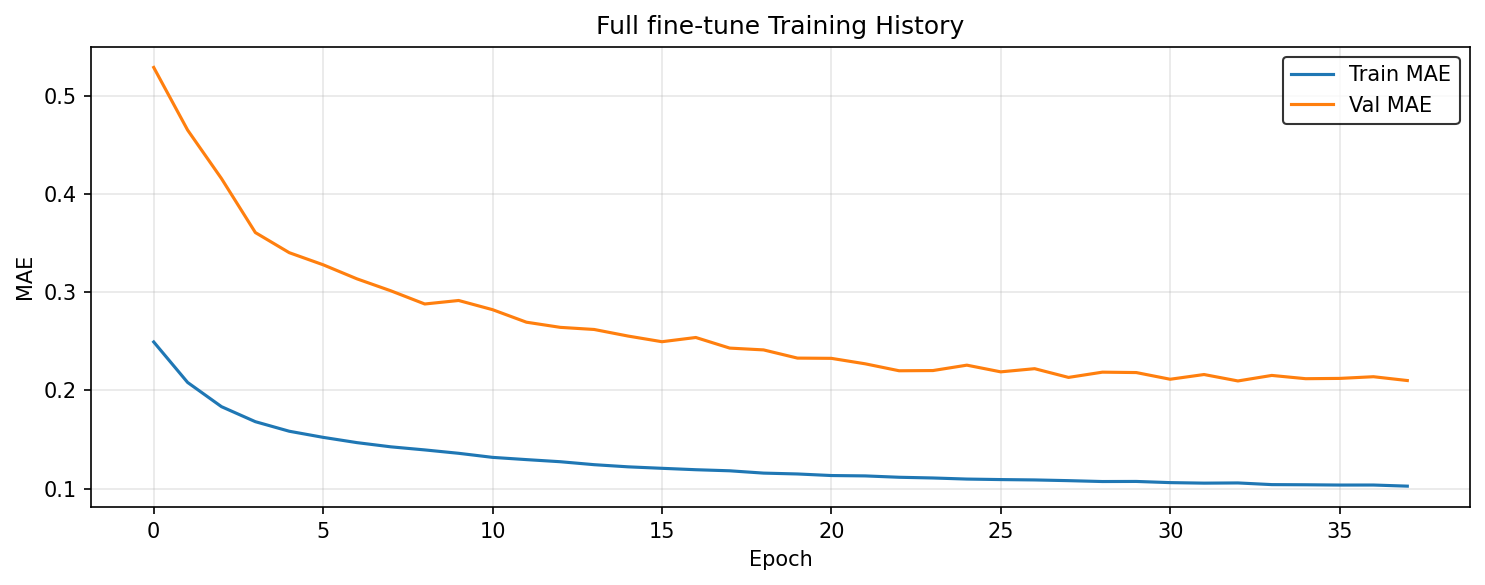

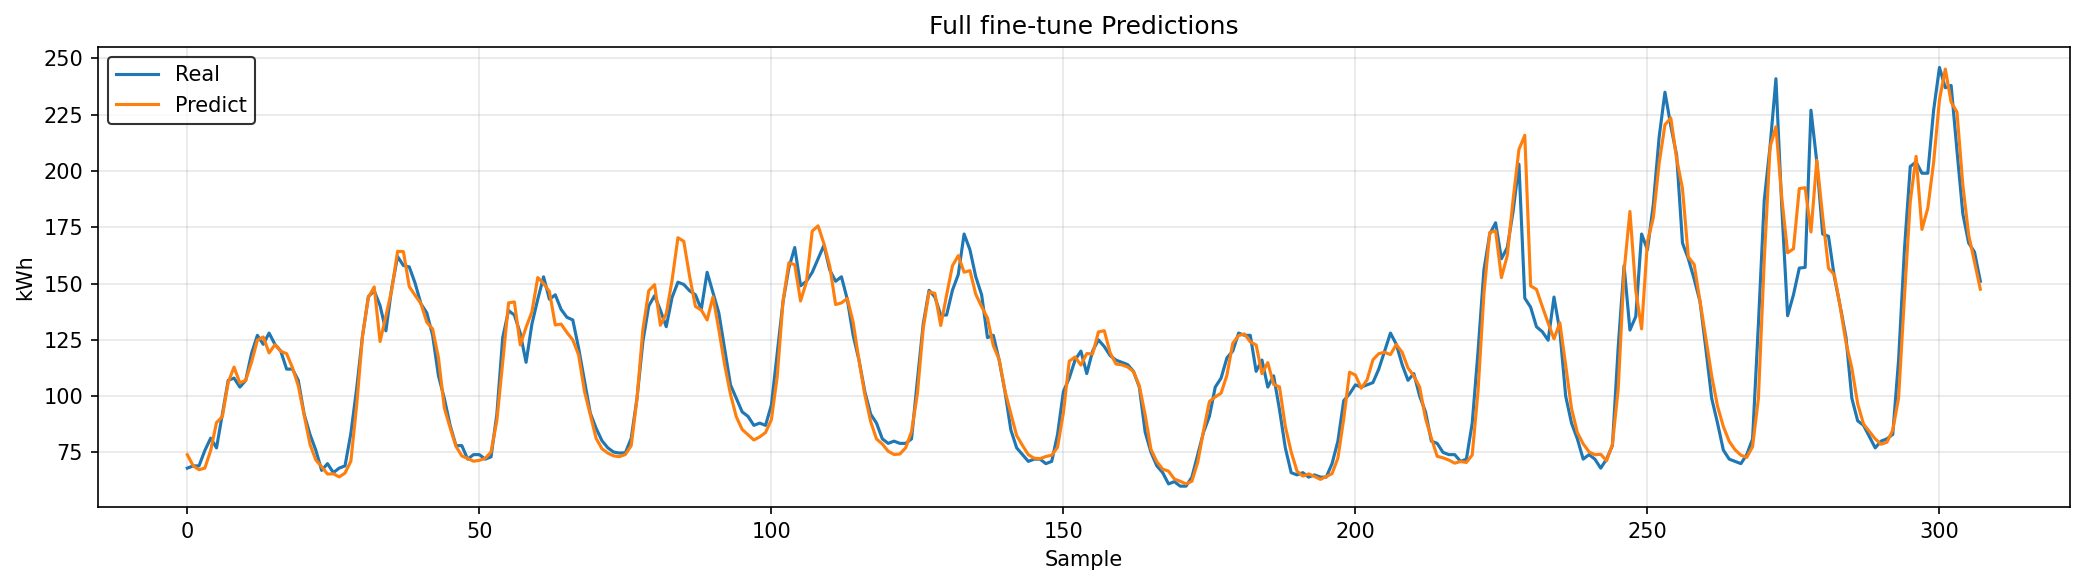

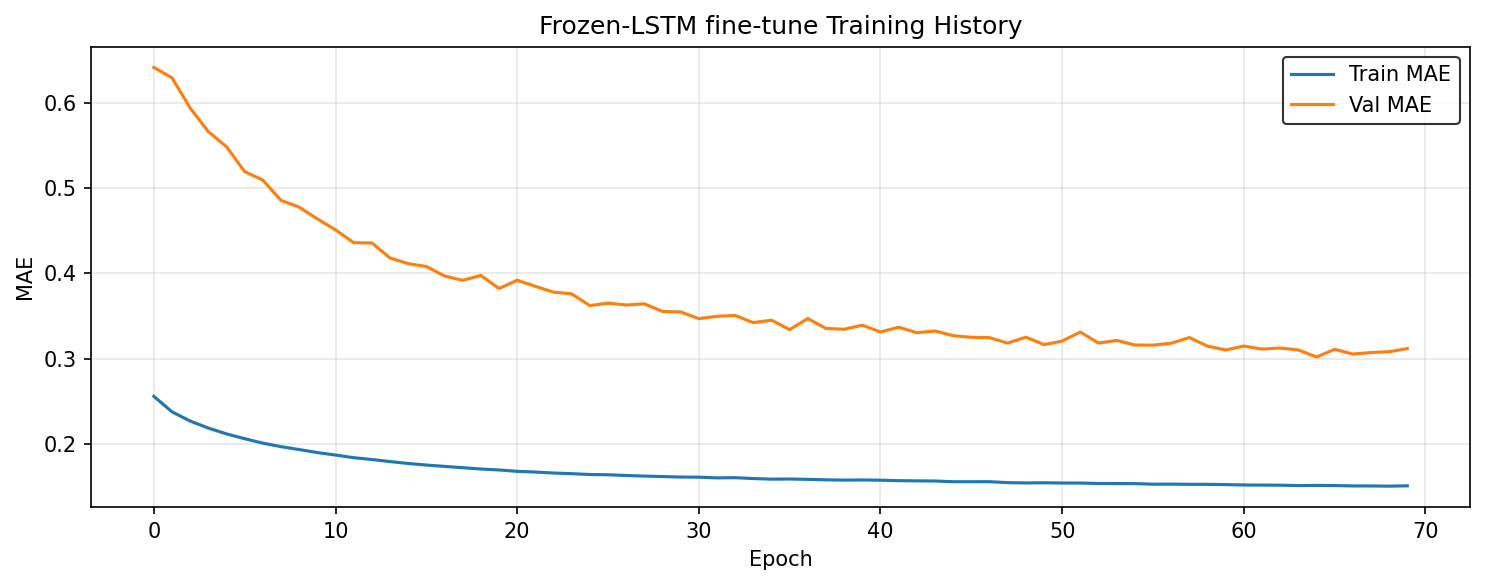

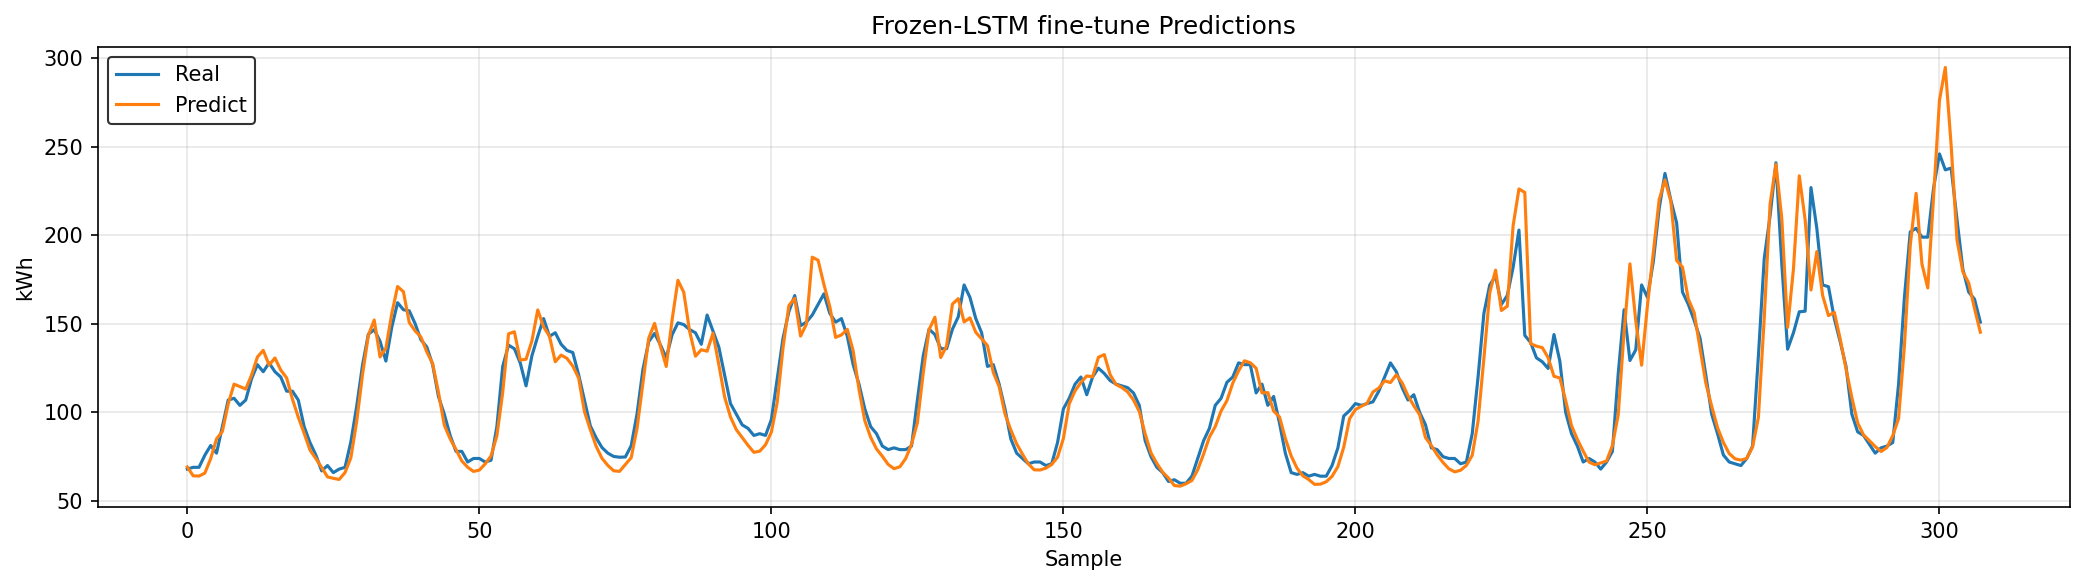

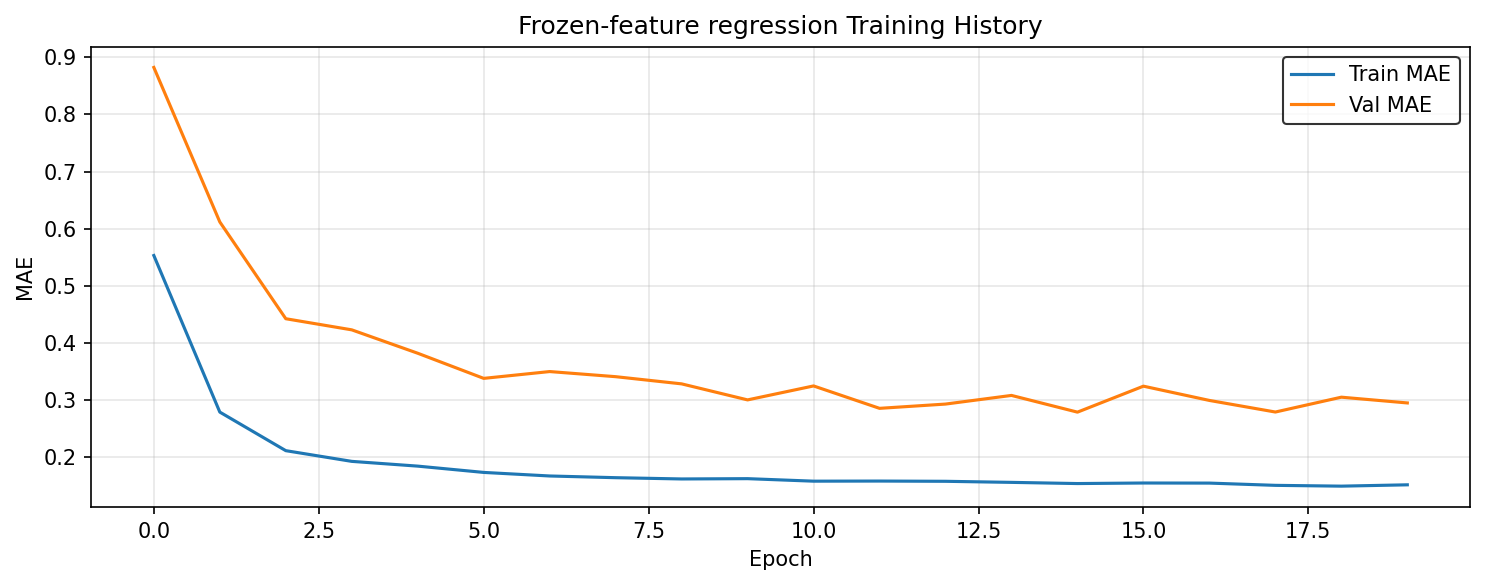

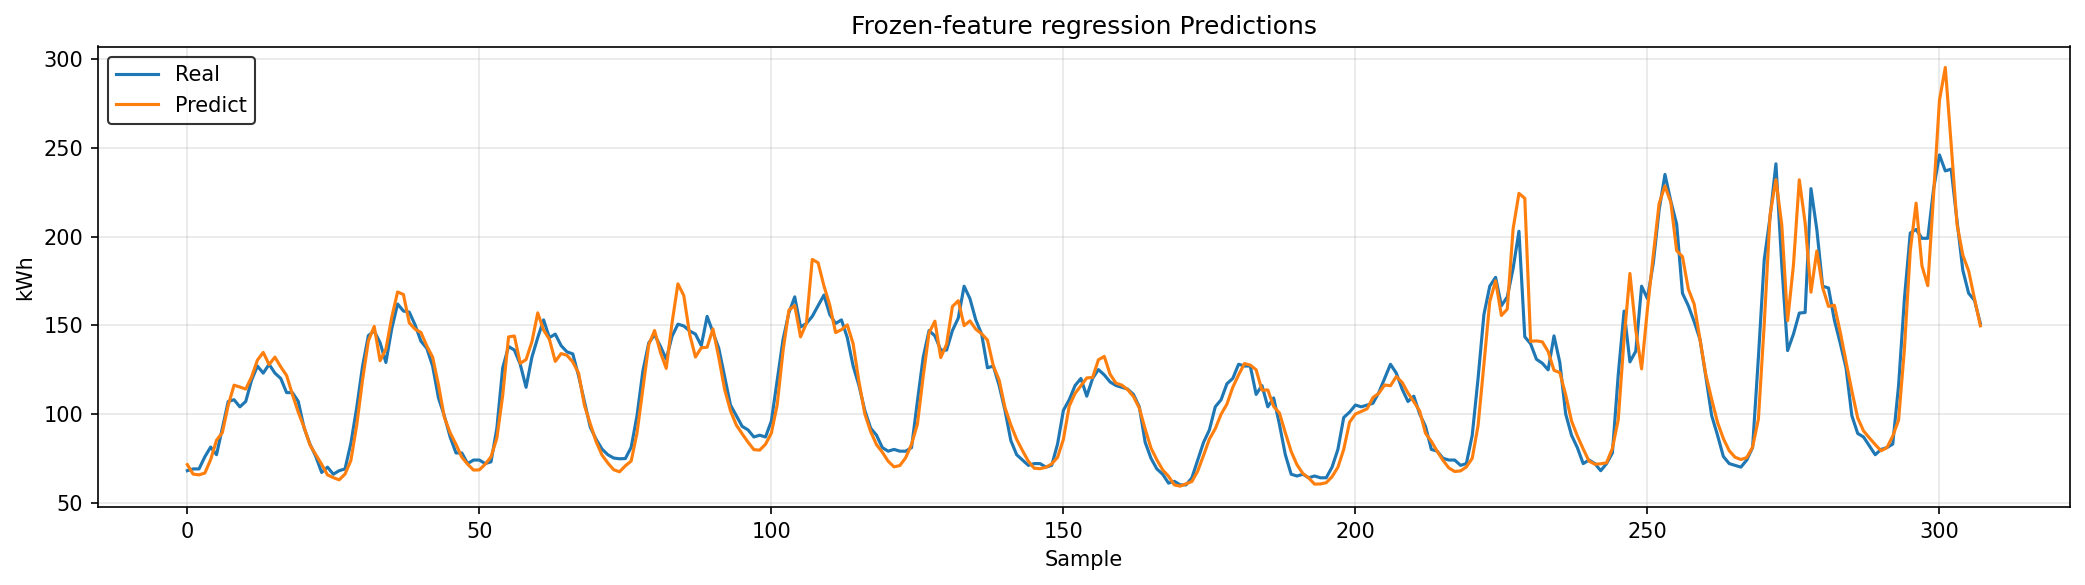

 >> 在 seed=42 下完成训练


,seed,策略,MAE,RMSE,CV-RMSE,MAPE,R2,best_epoch,best_val_loss,epochs
0,7,源域直测,10.667176,16.459100,13.928408,8.375003,0.835459,NaN,NaN,0
1,7,目标域训练,10.143272,14.424862,12.206946,8.120652,0.873618,12.0,0.311546,18
2,7,全层微调,6.583817,10.268144,8.689351,5.359600,0.935961,37.0,0.184891,43
3,7,冻结LSTM微调,7.738378,12.685864,10.735331,6.190551,0.902254,85.0,0.252012,91
4,7,冻结特征回归,7.589942,11.865964,10.041496,6.199568,0.914480,33.0,0.218240,39
5,21,源域直测,10.960800,15.704836,13.290116,8.760143,0.850194,NaN,NaN,0
6,21,目标域训练,10.786219,14.930230,12.634611,8.559388,0.864608,18.0,0.349387,24
7,21,全层微调,6.823071,10.736856,9.085996,5.491925,0.929981,23.0,0.209940,29
8,21,冻结LSTM微调,7.824582,13.114936,11.098430,6.052711,0.895530,46.0,0.327405,52
9,21,冻结特征回归,7.507938,12.428185,10.517271,5.862377,0.906184,12.0,0.292941,18


In [4]:
seed_results = []

for seed in [*REPEAT_SEEDS, SEED]:
    source_state = train_source(seed)
    results = [
        run_source_only(seed, source_state),
        run_target_only(seed),
        run_full_fine_tune(seed, source_state),
        run_frozen_lstm_fine_tune(seed, source_state),
        run_frozen_feature_regression(seed, source_state),
    ]
    seed_results.extend(results)
    print(f" >> 在 seed={seed} 下完成训练")

seed_results_df = pd.DataFrame(seed_results)
seed_results_df

## 实验结果汇总

In [5]:
def mean_ci(values, confidence: float = 0.95) -> tuple:
    arr = np.asarray(values, dtype=float)
    mean = arr.mean()
    std = arr.std(ddof=1)
    margin = stats.t.ppf((1 + confidence) / 2, len(arr) - 1) * stats.sem(arr)
    return mean, std, mean - margin, mean + margin, margin

summary_df = (
    seed_results_df.loc[seed_results_df['seed'] == SEED, ['策略', *METRIC_COLS]]
    .reset_index(drop=True)
)
seed_summary_rows = []
for strategy, group in seed_results_df.groupby('策略', sort=False):
    for metric in METRIC_COLS:
        mean, std, ci_low, ci_high, ci_margin = mean_ci(group[metric])
        seed_summary_rows.append({
            '策略': strategy,
            '指标': metric,
            'mean': mean,
            'std': std,
            'ci95_low': ci_low,
            'ci95_high': ci_high,
            'ci95_margin': ci_margin,
        })
seed_summary_df = pd.DataFrame(seed_summary_rows)

reference_strategy = '目标域训练'
seed_test_rows = []
strategies = [s for s in seed_results_df['策略'].unique() if s != reference_strategy]

for strategy in strategies:
    for metric in METRIC_COLS:
        reference = seed_results_df.loc[seed_results_df['策略'] == reference_strategy, ['seed', metric]]
        current = seed_results_df.loc[seed_results_df['策略'] == strategy, ['seed', metric]]
        paired = reference.merge(current, on='seed', suffixes=('_reference', '_strategy'))
        reference_values = paired[f'{metric}_reference'].to_numpy(dtype=float)
        strategy_values = paired[f'{metric}_strategy'].to_numpy(dtype=float)
        diff = strategy_values - reference_values
        mean_diff, _, ci_low, ci_high, _ = mean_ci(diff)
        t_stat, t_pvalue = stats.ttest_rel(strategy_values, reference_values)

        if np.allclose(diff, 0):
            w_stat, w_pvalue = np.nan, np.nan
        else:
            w_stat, w_pvalue = stats.wilcoxon(strategy_values, reference_values)

        if metric == 'R2':
            improvement_pct = np.mean((strategy_values - reference_values) / np.abs(reference_values)) * 100
        else:
            improvement_pct = np.mean((reference_values - strategy_values) / reference_values) * 100

        seed_test_rows.append({
            '策略': strategy,
            '指标': metric,
            'mean_diff_strategy_minus_reference': mean_diff,
            'diff_ci95_low': ci_low,
            'diff_ci95_high': ci_high,
            'mean_improvement_pct': improvement_pct,
            'paired_t_stat': t_stat,
            'paired_t_pvalue': t_pvalue,
            'wilcoxon_stat': w_stat,
            'wilcoxon_pvalue': w_pvalue,
        })
seed_tests_df = pd.DataFrame(seed_test_rows)

print(f'SEED={SEED} 结果：')
print(summary_df.to_string(index=False))

summary_df.to_csv(BASE_DIR / 'transfer_learning_results.csv', index=False, encoding='utf-8-sig')
seed_results_df.to_csv(BASE_DIR / 'transfer_learning_seed_results.csv', index=False, encoding='utf-8-sig')
seed_summary_df.to_csv(BASE_DIR / 'transfer_learning_seed_summary.csv', index=False, encoding='utf-8-sig')
seed_tests_df.to_csv(BASE_DIR / 'transfer_learning_seed_tests.csv', index=False, encoding='utf-8-sig')

SEED=42 结果：
      策略       MAE      RMSE   CV-RMSE     MAPE       R2
    源域直测 11.676472 17.007779 14.392724 9.377678 0.824306
   目标域训练  9.624496 13.672050 11.569885 7.735243 0.886465
    全层微调  6.639599 10.638321  9.002611 5.393939 0.931260
冻结LSTM微调  8.249588 13.304208 11.258600 6.666873 0.892492
  冻结特征回归  8.190755 13.224249 11.190935 6.627041 0.893781


## 结果分析

本 notebook 同时保留主 seed 的单次结果和多 seed 统计结果：

1. **主 seed 单次结果**：写入 `transfer_learning_results.csv`，供后续可视化 notebook 使用。

2. **多 seed 明细**：写入 `transfer_learning_seed_results.csv`，每行对应一个 seed 和一种策略。

3. **均值与置信区间**：写入 `transfer_learning_seed_summary.csv`，报告 mean、std 和 95% CI。

4. **配对统计检验**：写入 `transfer_learning_seed_tests.csv`，以目标域训练为主参照，报告 paired t-test 和 Wilcoxon 检验。源域直测用于衡量源域模型在未迁移到目标域时的直接预测能力。